# Notebook Sanity Check - Análisis de **un episodio**
- Unidad narrativa: **intervalo de decisión** → cadena causal (dinámica → control → métricas/reward → decisión RL → update).
- Fuente: **JSON en chunks de episodios**.

## Caja 0 - Imports + settings

In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Path del directorio de resultados
RUN_DIR = Path(r".../results_history_CartPole/cart_pole/20260302_1105")


## Caja 1 - Helpers mínimos

In [2]:
def extract_episode_id(ep):
    if isinstance(ep, dict) and 'episode_id' in ep:
        try:
            return int(ep['episode_id'])
        except Exception:
            return None
    if isinstance(ep, dict) and isinstance(ep.get('episode_data'), dict) and 'episode_id' in ep['episode_data']:
        try:
            return int(ep['episode_data']['episode_id'])
        except Exception:
            return None
    return None


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def discover_chunk_files(run_dir: Path):
    # Heurística simple: toma *.json y excluye metadata/config por nombre
    files = []
    for p in sorted(run_dir.resolve().rglob('*.json')):
        name = p.name.lower()
        if 'metadata' in name:
            continue
        if 'config' in name:
            continue
        files.append(p)
    return files


#def build_episode_index(chunk_paths):                  ### SE ELIMINA YA QUE ES MUY COSTOSO ESTE MÉTODO, RESUELTO MANUAL
#    # episode_id -> (chunk_path, index_in_chunk)
#    idx = {}
#    for cp in chunk_paths:
#        try:
#            obj = load_json(cp)
#        except Exception:
#            continue
#        episodes = list(iter_episode_dicts(obj))
#        for i, ep in enumerate(episodes):
#            eid = extract_episode_id(ep)
#            if eid is None:
#                continue
#            if eid not in idx:
#                idx[eid] = (cp, i)
#    return idx

def find_key_by_value(episode_index: dict, episode_id: int):
    for file_name, ep_groups in episode_index.items():
        if episode_id in ep_groups:
            return file_name, ep_groups.index(episode_id)
    return None, None
        
def load_episode_from_index(episode_index: dict, episode_id: int):
    dir_file, idx_episode_id = find_key_by_value(episode_index, episode_id)
    episodes = list(load_json(dir_file))
    ep_data = episodes[idx_episode_id]
    return ep_data, dir_file


def list_series_keys(d):
    return [k for k, v in d.items() if isinstance(k, str) and isinstance(v, list)]


def build_df(series_dict):
    keys = list_series_keys(series_dict)
    if not keys:
        return pd.DataFrame()

    lists = {k: series_dict[k] for k in keys if isinstance(series_dict.get(k), list)}
    if not lists:
        return pd.DataFrame()

    n = max(map(len, lists.values()))
    data = {k: v + [np.nan] * (n - len(v)) for k, v in lists.items()}
    return pd.DataFrame(data)

def absmax(s):
    if s is None or len(s) == 0:
        return None
    a = np.abs(pd.to_numeric(pd.Series(s), errors='coerce')).dropna()
    return float(a.max()) if len(a) else None

def add_interval_aggs(interval_df, step_df, agg_map,
                      start_col='interval_start_step_idx',
                      end_col='interval_end_step_idx'):
    out = interval_df.copy()

    for col, spec in agg_map.items():
        # spec puede ser 'mean' o ('mean', 'nombre_custom')
        agg, new_name = (spec, f'{col}_{spec}') if isinstance(spec, str) else spec

        vals = []
        for a, b in zip(out[start_col], out[end_col]):
            s = step_df.loc[a:b, col]
            if agg == 'bool_mean':
                vals.append(float(s.astype(bool).mean()))
            else:
                vals.append(float(getattr(s, agg)()))
        out[new_name] = vals

    return out


## Caja 2 - Discover chunks + index de episodios

In [3]:
chunk_files = discover_chunk_files(RUN_DIR)
print(f'chunks encontrados: {len(chunk_files)}')
chunk_files[:5]


chunks encontrados: 50


[WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260302_1105/episodes_chunks_0000.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260302_1105/episodes_chunks_0001.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260302_1105/episodes_chunks_0002.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260302_1105/episodes_chunks_0003.json'),
 WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260302_1105/episodes_chunks_0004.json')]

In [4]:
n_episodes = 5000
ep_for_file = int(n_episodes/len(chunk_files))
episode_index = {}
idx_i = 0
idx_f = 0
id_dir_file = 0
for cf in chunk_files:
    idx_f += ep_for_file
    episode_index[cf] = list(range(idx_i, idx_f))
    idx_i = idx_f
    id_dir_file += 1
list(episode_index.items())[-2:]

[(WindowsPath('C:/Users/davor/Escritorio/DOCTORADO/Tesis/RL_5_SimpleSystemSimulator/results_history_CartPole/cart_pole/20260302_1105/episodes_chunks_0048.json'),
  [4800,
   4801,
   4802,
   4803,
   4804,
   4805,
   4806,
   4807,
   4808,
   4809,
   4810,
   4811,
   4812,
   4813,
   4814,
   4815,
   4816,
   4817,
   4818,
   4819,
   4820,
   4821,
   4822,
   4823,
   4824,
   4825,
   4826,
   4827,
   4828,
   4829,
   4830,
   4831,
   4832,
   4833,
   4834,
   4835,
   4836,
   4837,
   4838,
   4839,
   4840,
   4841,
   4842,
   4843,
   4844,
   4845,
   4846,
   4847,
   4848,
   4849,
   4850,
   4851,
   4852,
   4853,
   4854,
   4855,
   4856,
   4857,
   4858,
   4859,
   4860,
   4861,
   4862,
   4863,
   4864,
   4865,
   4866,
   4867,
   4868,
   4869,
   4870,
   4871,
   4872,
   4873,
   4874,
   4875,
   4876,
   4877,
   4878,
   4879,
   4880,
   4881,
   4882,
   4883,
   4884,
   4885,
   4886,
   4887,
   4888,
   4889,
   4890,
   4891,
   4892,
 

## Caja 3 - Cargar episodio

In [5]:
EPISODE_ID = 4500

In [6]:
episode, source_chunk = load_episode_from_index(episode_index, EPISODE_ID)
print('source_chunk:', source_chunk)
print('episode keys:', list(episode.keys()))

step_data = episode.get('step_data', {})
interval_data = episode.get('interval_data', {})
end_data = episode.get('end_episode_data', {})

print('step_data keys:', len(step_data))
print('interval_data keys:', len(interval_data))
print('end_data keys:', len(end_data))


source_chunk: C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5_SimpleSystemSimulator\results_history_CartPole\cart_pole\20260302_1105\episodes_chunks_0045.json
episode keys: ['episode_id', 'step_data', 'interval_data', 'end_episode_data']
step_data keys: 37
interval_data keys: 37
end_data keys: 8


## Caja 4 - DataFrames step/interval

In [7]:
step_df = build_df(step_data)
interval_df = build_df(interval_data)

print('step_df shape:', step_df.shape)
step_df.head(3)


step_df shape: (2373, 36)


,t_sec,cart_position_raw,cart_velocity_raw,pendulum_angle_raw,pendulum_velocity_raw,cart_position_norm,cart_velocity_norm,pendulum_angle_norm,pendulum_velocity_norm,cart_force,...,u_eff_pendulum_angle,u_eff_cart_position,delta_u_eff_pendulum_angle,delta_u_eff_cart_position,kp_pendulum_angle,kp_cart_position,ki_pendulum_angle,ki_cart_position,kd_pendulum_angle,kd_cart_position
0,0.000,0.000000e+00,0.000000,0.157000,0.000000,0.000000e+00,0.000000,0.149924,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0
1,0.001,5.063491e-07,0.001013,0.157000,0.000534,1.012698e-07,0.000127,0.149924,0.000133,6.603235,...,0.165081,0.000000,0.165081,0.000000,1.1,1.1,1.1,1.1,1.1,1.1
2,0.002,2.026724e-06,0.002028,0.157001,0.001065,4.053449e-07,0.000254,0.149925,0.000266,6.616593,...,0.165526,-0.000112,0.000445,-0.000112,1.1,1.1,1.1,1.1,1.1,1.1


In [8]:
step_df.columns

Index(['t_sec', 'cart_position_raw', 'cart_velocity_raw', 'pendulum_angle_raw',
       'pendulum_velocity_raw', 'cart_position_norm', 'cart_velocity_norm',
       'pendulum_angle_norm', 'pendulum_velocity_norm', 'cart_force',
       'u_total', 'u_total_raw', 'is_saturated_global', 'delta_u_total',
       'error_pendulum_angle', 'error_cart_position',
       'delta_error_pendulum_angle', 'delta_error_cart_position',
       'derivative_error_pendulum_angle', 'derivative_error_cart_position',
       'integral_error_pendulum_angle', 'integral_error_cart_position',
       'control_action_pendulum_angle', 'control_action_cart_position',
       'delta_control_action_pendulum_angle',
       'delta_control_action_cart_position', 'u_eff_pendulum_angle',
       'u_eff_cart_position', 'delta_u_eff_pendulum_angle',
       'delta_u_eff_cart_position', 'kp_pendulum_angle', 'kp_cart_position',
       'ki_pendulum_angle', 'ki_cart_position', 'kd_pendulum_angle',
       'kd_cart_position'],
      dtype=

In [9]:
print('interval_df shape:', interval_df.shape)
interval_df.head(5)


interval_df shape: (119, 36)


,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_n_steps,L_e_pendulum_angle,L_e_cart_position,L_edot_pendulum_angle,L_edot_cart_position,L_delta_u_pendulum_angle,...,reward_kp_pendulum_angle,reward_ki_pendulum_angle,reward_kd_pendulum_angle,reward_kp_cart_position,reward_ki_cart_position,reward_kd_cart_position,extra_bonus_band_pendulum_angle,extra_bonus_band_cart_position,extra_conditional_dynamic_penalty_pendulum_angle,extra_conditional_dynamic_penalty_cart_position
0,0,0,19,0.00,20,0.022486,2.988659e-10,0.000027,0.000014,0.136303,...,-0.028329,-0.028329,-0.028329,-0.000008,-0.000008,-0.000008,3.0,3.0,-0.008252,-8.547490e-07
1,1,20,39,0.02,20,0.022539,1.069923e-08,0.000155,0.000119,0.001461,...,-0.008186,-0.008186,-0.008186,-0.000061,-0.000061,-0.000061,3.0,3.0,-0.011267,-1.213927e-05
2,2,40,59,0.04,20,0.022630,8.185978e-08,0.000293,0.000382,0.001591,...,-0.008306,-0.008306,-0.008306,-0.000194,-0.000194,-0.000194,3.0,3.0,-0.014527,-4.782069e-05
3,3,60,79,0.06,20,0.022741,3.351883e-07,0.000372,0.000849,0.001681,...,-0.008397,-0.008397,-0.008397,-0.000430,-0.000430,-0.000430,3.0,3.0,-0.017928,-1.266414e-04
4,4,80,99,0.08,20,0.022859,9.840913e-07,0.000379,0.001557,0.001739,...,-0.008451,-0.008451,-0.008451,-0.000788,-0.000788,-0.000788,3.0,3.0,-0.021402,-2.727095e-04


In [10]:
interval_df.columns

Index(['interval_id', 'interval_start_step_idx', 'interval_end_step_idx',
       'interval_t_start_sec', 'interval_n_steps', 'L_e_pendulum_angle',
       'L_e_cart_position', 'L_edot_pendulum_angle', 'L_edot_cart_position',
       'L_delta_u_pendulum_angle', 'L_delta_u_cart_position',
       'error_pendulum_angle_mean_squared', 'error_cart_position_mean_squared',
       'derivative_error_pendulum_angle_mean_squared',
       'derivative_error_cart_position_mean_squared',
       'delta_u_eff_pendulum_angle_mean_squared',
       'delta_u_eff_cart_position_mean_squared',
       'integral_error_pendulum_angle_mean_squared',
       'integral_error_cart_position_mean_squared', 'action_kp_pendulum_angle',
       'action_ki_pendulum_angle', 'action_kd_pendulum_angle',
       'action_kp_cart_position', 'action_ki_cart_position',
       'action_kd_cart_position', 'global_interval_reward',
       'reward_kp_pendulum_angle', 'reward_ki_pendulum_angle',
       'reward_kd_pendulum_angle', 'reward_kp_

## Caja 5 - Ficha del episodio

In [11]:
n_steps = len(step_df) if len(step_df) else int(step_data.get('n_step', 0) or 0)
n_intervals = len(interval_df) if len(interval_df) else int(interval_data.get('n_interval', 0) or 0)

sat_prp = float(step_df['is_saturated_global'].astype(bool).mean())

card = {
    'episode_id': EPISODE_ID,
    'n_steps': n_steps,
    'n_intervals': n_intervals,
    'pendulum_angle_mean': float(step_df['pendulum_angle_raw'].mean()),
    'pendulum_angle_min': float(step_df['pendulum_angle_raw'].min()),
    'pendulum_angle_max': float(step_df['pendulum_angle_raw'].max()),
    'cart_position_mean': float(step_df['cart_position_raw'].mean()),
    'cart_position_min': float(step_df['cart_position_raw'].min()),
    'cart_position_max': float(step_df['cart_position_raw'].max()),
    'u_total_mean': float(step_df['u_total'].mean()),
    'u_total_min': float(step_df['u_total'].min()),
    'u_total_max': float(step_df['u_total'].max()),
    'sat_prp_steps': sat_prp,
    'reward_sum_kp_pendulum_angle': float(pd.to_numeric(interval_df['reward_kp_pendulum_angle'], errors='coerce').fillna(0).sum()),
    'reward_mean_kp_pendulum_angle': float(pd.to_numeric(interval_df['reward_kp_pendulum_angle'], errors='coerce').fillna(0).mean()),
    'reward_sum_ki_pendulum_angle': float(pd.to_numeric(interval_df['reward_ki_pendulum_angle'], errors='coerce').fillna(0).sum()),
    'reward_mean_ki_pendulum_angle': float(pd.to_numeric(interval_df['reward_ki_pendulum_angle'], errors='coerce').fillna(0).mean()),
    'reward_sum_kd_pendulum_angle': float(pd.to_numeric(interval_df['reward_kd_pendulum_angle'], errors='coerce').fillna(0).sum()),
    'reward_mean_kd_pendulum_angle': float(pd.to_numeric(interval_df['reward_kd_pendulum_angle'], errors='coerce').fillna(0).mean()),
    'reward_sum_kp_cart_position': float(pd.to_numeric(interval_df['reward_kp_cart_position'], errors='coerce').fillna(0).sum()),
    'reward_mean_kp_cart_position': float(pd.to_numeric(interval_df['reward_kp_cart_position'], errors='coerce').fillna(0).mean()),
    'reward_sum_ki_cart_position': float(pd.to_numeric(interval_df['reward_ki_cart_position'], errors='coerce').fillna(0).sum()),
    'reward_mean_ki_cart_position': float(pd.to_numeric(interval_df['reward_ki_cart_position'], errors='coerce').fillna(0).mean()),
    'reward_sum_kd_cart_position': float(pd.to_numeric(interval_df['reward_kd_cart_position'], errors='coerce').fillna(0).sum()),
    'reward_mean_kd_cart_position': float(pd.to_numeric(interval_df['reward_kd_cart_position'], errors='coerce').fillna(0).mean()),
    'reward_sum_intervals': float(pd.to_numeric(interval_df['global_interval_reward'], errors='coerce').fillna(0).sum()),
}
card


{'episode_id': 4500,
 'n_steps': 2373,
 'n_intervals': 119,
 'pendulum_angle_mean': 0.27540702531603006,
 'pendulum_angle_min': 0.15700000000000003,
 'pendulum_angle_max': 0.7384087871882441,
 'cart_position_mean': 1.5263797484409283,
 'cart_position_min': 0.0,
 'cart_position_max': 5.001107708252934,
 'u_total_mean': 0.3649521640568252,
 'u_total_min': 0.0,
 'u_total_max': 1.0,
 'sat_prp_steps': 0.03876949009692372,
 'reward_sum_kp_pendulum_angle': -12.210977351728296,
 'reward_mean_kp_pendulum_angle': -0.1026132550565403,
 'reward_sum_ki_pendulum_angle': -12.210977351728296,
 'reward_mean_ki_pendulum_angle': -0.1026132550565403,
 'reward_sum_kd_pendulum_angle': -12.210977351728296,
 'reward_mean_kd_pendulum_angle': -0.1026132550565403,
 'reward_sum_kp_cart_position': -36.72073586152729,
 'reward_mean_kp_cart_position': -0.3085776122817419,
 'reward_sum_ki_cart_position': -36.72073586152729,
 'reward_mean_ki_cart_position': -0.3085776122817419,
 'reward_sum_kd_cart_position': -36.7207

In [12]:
end_data

{'end_terminated': True,
 'end_termination_reason': 'limit_exceeded',
 'accumulated_band_bonus': 37.5,
 'goal_bonus': 0.0,
 'total_reward': -455.94391426967707,
 'total_agent_decisions': 119,
 'epsilon': 0.01,
 'learning_rate': 0.01}

## Caja 6 - Timeline del episodio (por intervalos)

In [18]:
cols = [
    'interval_id',
    'interval_start_step_idx',
    'interval_end_step_idx',
    'interval_n_steps',
    'global_interval_reward',
    'error_pendulum_angle_mean_squared', 
    'error_cart_position_mean_squared',
    'derivative_error_pendulum_angle_mean_squared',
    'derivative_error_cart_position_mean_squared',
    'delta_u_eff_pendulum_angle_mean_squared', 
    'delta_u_eff_cart_position_mean_squared',
]
interval_timeline_df = interval_df[cols].copy()

agg_map = {
    'pendulum_angle_raw': ('mean', 'pendulum_angle_mean'),
    'pendulum_velocity_raw': ('mean', 'pendulum_velocity_mean'),
    'cart_position_raw': ('mean', 'cart_position_mean'),
    'cart_velocity_raw': ('mean', 'cart_velocity_mean'),
    'cart_force': ('mean', 'cart_force_mean'),

    'kp_pendulum_angle': ('mean', 'kp_pendulum_angle_mean'),
    'ki_pendulum_angle': ('mean', 'ki_pendulum_angle_mean'),
    'kd_pendulum_angle': ('mean', 'kd_pendulum_angle_mean'),
    'kp_cart_position': ('mean', 'kp_cart_position_mean'),
    'ki_cart_position': ('mean', 'ki_cart_position_mean'),
    'kd_cart_position': ('mean', 'kd_cart_position_mean'),

    'control_action_pendulum_angle': ('mean', 'u_calc_pendulum_mean'),
    'error_pendulum_angle': ('mean', 'e_pendulum_mean'),
    'derivative_error_pendulum_angle': ('mean', 'edot_pendulum_mean'),
    'integral_error_pendulum_angle': ('mean', 'eint_pendulum_mean'),

    'control_action_cart_position': ('mean', 'u_calc_cart_mean'),
    'error_cart_position': ('mean', 'e_cart_mean'),
    'derivative_error_cart_position': ('mean', 'edot_cart_mean'),
    'integral_error_cart_position': ('mean', 'eint_cart_mean'),

    'is_saturated_global': ('bool_mean', 'sat_prp_interval'),

    'u_total': ('mean', 'u_total_mean'),
    'delta_u_eff_pendulum_angle': ('mean', 'delta_u_eff_pendulum_mean'),
    'delta_u_eff_cart_position': ('mean', 'delta_u_eff_cart_mean'),

}
interval_timeline_df = add_interval_aggs(interval_timeline_df, step_df, agg_map)

end_cols_add = [
    'L_e_pendulum_angle', 'L_edot_pendulum_angle', 'L_delta_u_pendulum_angle',
    'L_e_cart_position', 'L_edot_cart_position','L_delta_u_cart_position',
    'reward_kp_pendulum_angle', 'reward_ki_pendulum_angle', 'reward_kd_pendulum_angle',
    'reward_kp_cart_position', 'reward_ki_cart_position', 'reward_kd_cart_position'
]
interval_timeline_df = interval_timeline_df.join(interval_df[end_cols_add])

interval_timeline_df

,interval_id,interval_start_step_idx,interval_end_step_idx,interval_n_steps,global_interval_reward,error_pendulum_angle_mean_squared,error_cart_position_mean_squared,derivative_error_pendulum_angle_mean_squared,derivative_error_cart_position_mean_squared,delta_u_eff_pendulum_angle_mean_squared,...,L_delta_u_pendulum_angle,L_e_cart_position,L_edot_cart_position,L_delta_u_cart_position,reward_kp_pendulum_angle,reward_ki_pendulum_angle,reward_kd_pendulum_angle,reward_kp_cart_position,reward_ki_cart_position,reward_kd_cart_position
0,0,0,19,20,5.963410,0.022486,2.988659e-10,0.000027,0.000005,0.001363,...,0.136303,2.988659e-10,0.000014,0.000005,-0.028329,-0.028329,-0.028329,-0.000008,-0.000008,-0.000008
1,1,20,39,20,5.980474,0.022539,1.069923e-08,0.000155,0.000043,0.000015,...,0.001461,1.069923e-08,0.000119,0.000011,-0.008186,-0.008186,-0.008186,-0.000061,-0.000061,-0.000061
2,2,40,59,20,5.976926,0.022630,8.185978e-08,0.000293,0.000137,0.000016,...,0.001591,8.185978e-08,0.000382,0.000021,-0.008306,-0.008306,-0.008306,-0.000194,-0.000194,-0.000194
3,3,60,79,20,5.973118,0.022741,3.351883e-07,0.000372,0.000305,0.000017,...,0.001681,3.351883e-07,0.000849,0.000037,-0.008397,-0.008397,-0.008397,-0.000430,-0.000430,-0.000430
4,4,80,99,20,5.969086,0.022859,9.840913e-07,0.000379,0.000561,0.000017,...,0.001739,9.840913e-07,0.001557,0.000059,-0.008451,-0.008451,-0.008451,-0.000788,-0.000788,-0.000788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,114,2280,2299,20,-12.866155,0.394604,8.310043e-01,0.794158,1.039286,0.052045,...,1.000000,8.310043e-01,1.000000,1.000000,-0.685191,-0.685191,-0.685191,-0.940852,-0.940852,-0.940852
115,115,2300,2319,20,-12.517819,0.417522,8.691138e-01,0.823128,1.094202,0.046091,...,1.000000,8.691138e-01,1.000000,1.000000,-0.707697,-0.707697,-0.707697,-0.954190,-0.954190,-0.954190
116,116,2320,2339,20,-11.926743,0.441580,9.090896e-01,0.861182,1.150335,0.014879,...,1.000000,9.090896e-01,1.000000,1.000000,-0.735144,-0.735144,-0.735144,-0.968181,-0.968181,-0.968181
117,117,2340,2359,20,-11.708627,0.466945,9.509957e-01,0.909011,1.207684,0.069738,...,1.000000,9.509957e-01,1.000000,1.000000,-0.767937,-0.767937,-0.767937,-0.982848,-0.982848,-0.982848


In [19]:
interval_timeline_df.columns

Index(['interval_id', 'interval_start_step_idx', 'interval_end_step_idx',
       'interval_n_steps', 'global_interval_reward',
       'error_pendulum_angle_mean_squared', 'error_cart_position_mean_squared',
       'derivative_error_pendulum_angle_mean_squared',
       'derivative_error_cart_position_mean_squared',
       'delta_u_eff_pendulum_angle_mean_squared',
       'delta_u_eff_cart_position_mean_squared', 'pendulum_angle_mean',
       'pendulum_velocity_mean', 'cart_position_mean', 'cart_velocity_mean',
       'cart_force_mean', 'kp_pendulum_angle_mean', 'ki_pendulum_angle_mean',
       'kd_pendulum_angle_mean', 'kp_cart_position_mean',
       'ki_cart_position_mean', 'kd_cart_position_mean',
       'u_calc_pendulum_mean', 'e_pendulum_mean', 'edot_pendulum_mean',
       'eint_pendulum_mean', 'u_calc_cart_mean', 'e_cart_mean',
       'edot_cart_mean', 'eint_cart_mean', 'sat_prp_interval', 'u_total_mean',
       'delta_u_eff_pendulum_mean', 'delta_u_eff_cart_mean',
       'L_e_pend

In [20]:
dynamic_interval_df = interval_timeline_df.iloc[:,16:20]
#pd.plotting.scatter_matrix(dynamic_interval_df, figsize=(10,6));

In [21]:
dynamic_interval_df = interval_timeline_df.iloc[:,20:24]
#pd.plotting.scatter_matrix(dynamic_interval_df, figsize=(10,6));

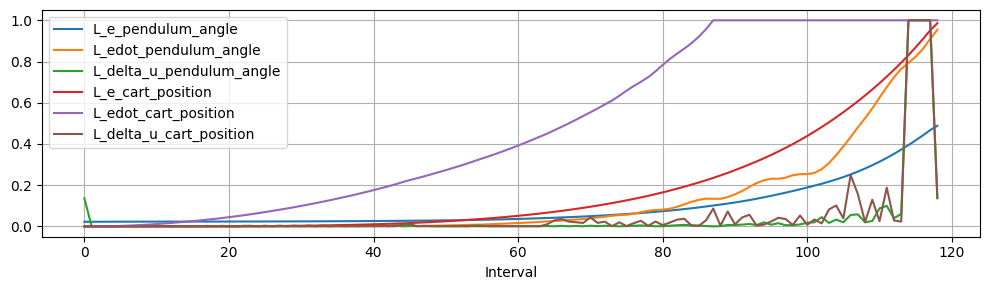

In [22]:
y_cols = ['L_e_pendulum_angle', 'L_edot_pendulum_angle','L_delta_u_pendulum_angle', 
          'L_e_cart_position', 'L_edot_cart_position','L_delta_u_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

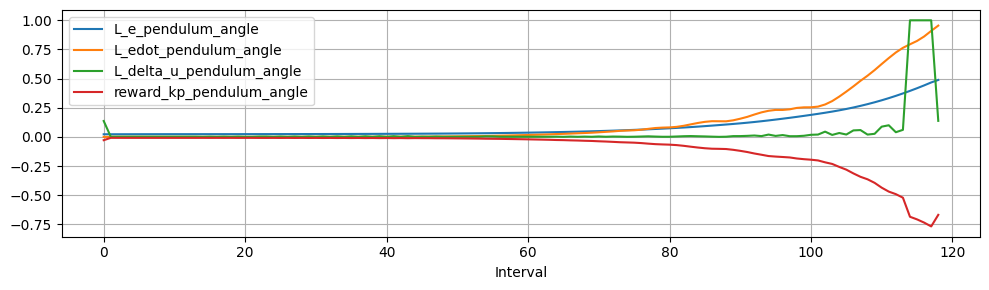

In [23]:
y_cols = ['L_e_pendulum_angle', 'L_edot_pendulum_angle','L_delta_u_pendulum_angle', 'reward_kp_pendulum_angle']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

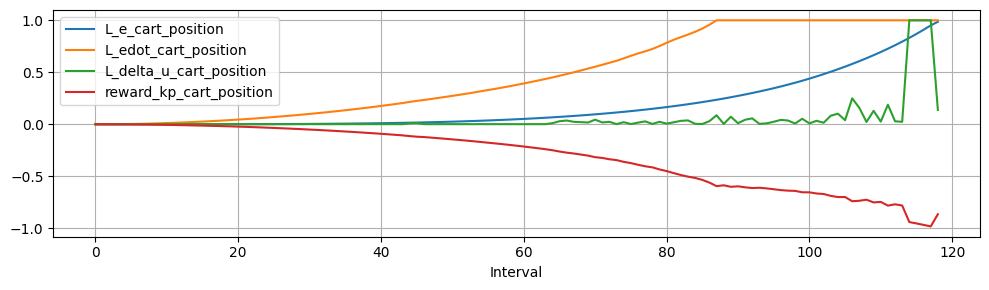

In [24]:
y_cols = ['L_e_cart_position', 'L_edot_cart_position','L_delta_u_cart_position', 'reward_kp_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
plt.tight_layout()
plt.show()

## Caja 7 - Timeline del episodio (por step)

In [25]:
def plot_many_columns(
    df, cols, colors, styles, alphas,
    col_names=None,
    title="Análisis", figsize=(14, 5),
    interval_lines=interval_df['interval_end_step_idx'],
    x_col=None,              # None => steps, 't_sec' => tiempo (s)
    y_lim=None,
):
    """
    Genera un gráfico multi-eje para análisis de señales de simulación.
    """
    x_step = np.arange(len(df)) if x_col is None else df[x_col].to_numpy()

    label_size = 16
    tick_size = 14
    legend_size = 10

    if col_names is None:
        col_names = cols
    col_names = (list(col_names) + list(cols))[:len(cols)]

    fig, ax_main = plt.subplots(figsize=figsize)
    axes = [ax_main]

    ax_main.set_title(title, fontsize=label_size + 2, pad=20)
    ax_main.set_xlabel("Steps (-)" if x_col is None else f"{x_col} (s)", fontsize=label_size)
    ax_main.grid(True, linestyle=':', alpha=0.7)

    for i in range(1, len(cols)):
        new_ax = ax_main.twinx()
        if i > 1:
            new_ax.spines['right'].set_position(('outward', 70 * (i-1)))
        axes.append(new_ax)

    for i, (col, name, color, style, a) in enumerate(zip(cols, col_names, colors, styles, alphas)):
        if col in df.columns:
            ax = axes[i]
            ax.plot(x_step, df[col], label=name, color=color, linestyle=style, alpha=a)
            ax.set_ylabel(name, color=color, fontsize=label_size, fontweight='bold')
            ax.tick_params(axis='x', labelsize=tick_size)
            ax.tick_params(axis='y', labelcolor=color, labelsize=tick_size)
            if i > 0:
                ax.spines['right'].set_color(color)
            if y_lim is not None:
                ax.set_ylim(y_lim)

    # interval lines: si x_col es tiempo, sigue dibujando en step (más simple y robusto)
    for s in pd.to_numeric(interval_lines, errors='coerce').dropna().astype(int).tolist():
        ax_main.axvline(x=(s if x_col is None else x_step[s]), color='gray', alpha=0.3,
                        linestyle=':', linewidth=0.8)

    if 'is_saturated_global' in df.columns:
        ax_main.fill_between(
            x_step, 0, 1, where=df['is_saturated_global'],
            color='red', alpha=0.1, transform=ax_main.get_xaxis_transform()
        )

    lines, labels = [], []
    for ax in axes:
        l, lb = ax.get_legend_handles_labels()
        lines.extend(l); labels.extend(lb)
    ax_main.legend(lines, labels, loc='upper left', fontsize=legend_size)

    plt.tight_layout()
    plt.show()

### Sanity check: Dynamic Data

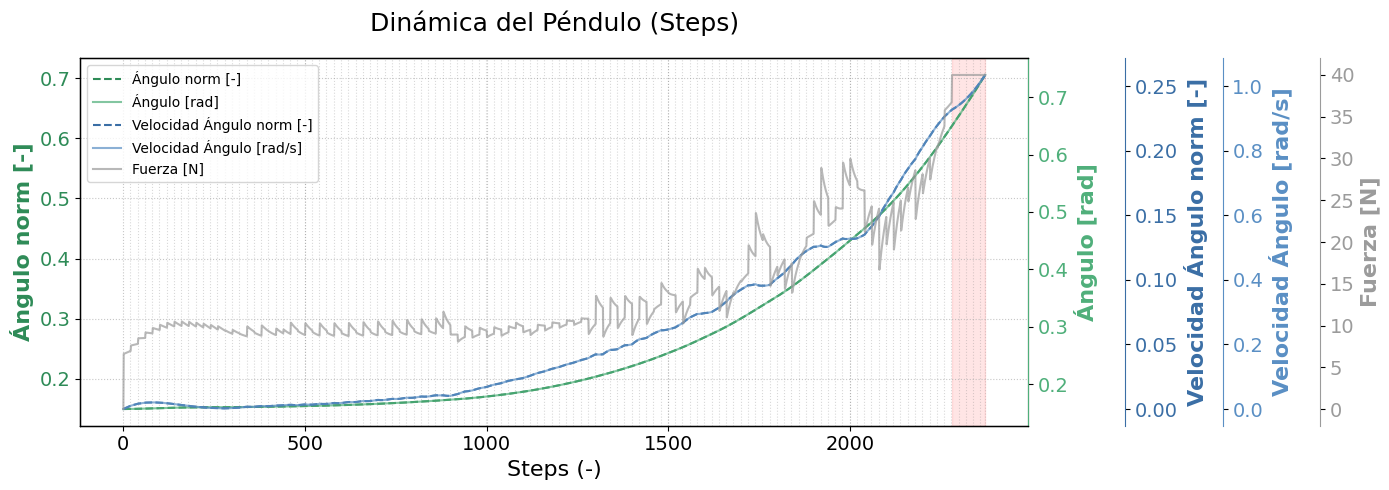

In [26]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['pendulum_angle_norm', 'pendulum_angle_raw', 'pendulum_velocity_norm', 'pendulum_velocity_raw', 'cart_force']
col_names    = ['Ángulo norm [-]', 'Ángulo [rad]', 'Velocidad Ángulo norm [-]', 'Velocidad Ángulo [rad/s]', 'Fuerza [N]']

# Verde sobrio + Azul sobrio
colors = ['#2E8B57', '#4FAF7A', '#3A6EA5', '#5A8FC4', '#9b9b9b']
styles = ['--', '-', '--', '-', '-']
alphas  = [1.0, 0.7, 1.0, 0.7, 0.7]
title  = "Dinámica del Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

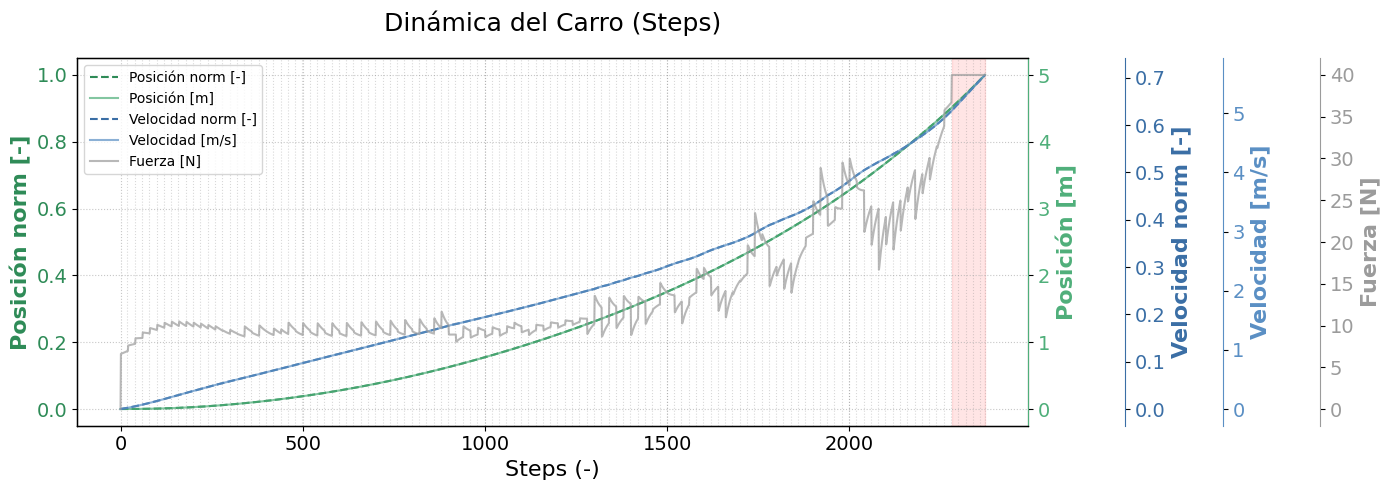

In [27]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['cart_position_norm', 'cart_position_raw', 'cart_velocity_norm', 'cart_velocity_raw', 'cart_force']
col_names = ['Posición norm [-]', 'Posición [m]', 'Velocidad norm [-]', 'Velocidad [m/s]', 'Fuerza [N]']

# Verde sobrio + Azul sobrio
colors = ['#2E8B57', '#4FAF7A', '#3A6EA5', '#5A8FC4', '#9b9b9b']
styles = ['--', '-', '--', '-', '-']
alphas = [1.0, 0.7, 1.0, 0.7, 0.7]
title  = "Dinámica del Carro (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

### Sanity check: Controller Data

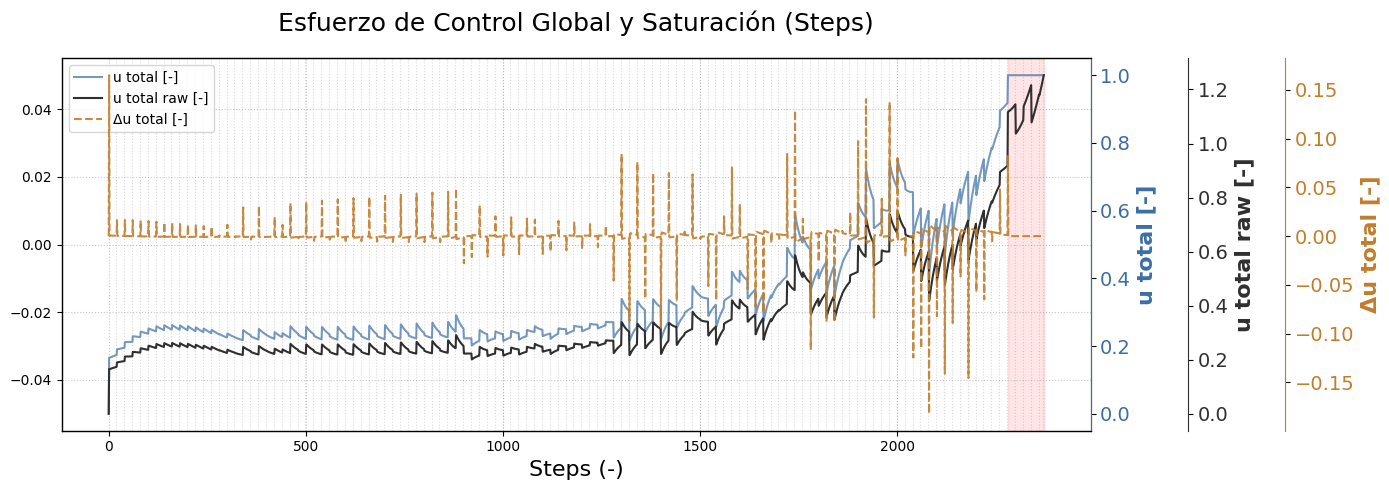

In [28]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['u_total_saturated', 'u_total', 'u_total_raw', 'delta_u_total']

col_names = ['u saturada [-]', 'u total [-]', 'u total raw [-]', 'Δu total [-]']

colors = ['#5A8FC4', '#3A6EA5', '#2F2F2F', '#C27D2C']
styles = ['--', '-', '-', '--']
alphas  = [1.0, 0.7, 1.0, 0.9]
title  = "Esfuerzo de Control Global y Saturación (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

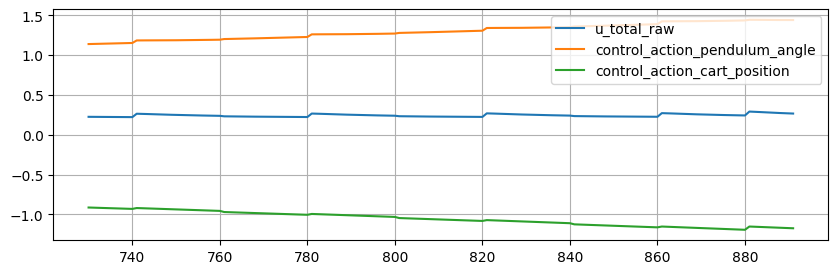

In [29]:
step_df.loc[730:891, 'u_total_raw'].plot()
step_df.loc[730:891, 'control_action_pendulum_angle'].plot()
step_df.loc[730:891, 'control_action_cart_position'].plot(figsize=(10, 3), grid=True)

plt.legend()

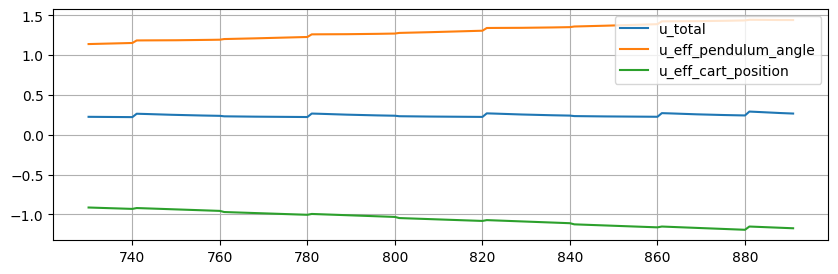

In [30]:
step_df.loc[730:891, 'u_total'].plot()
step_df.loc[730:891, 'u_eff_pendulum_angle'].plot()
step_df.loc[730:891, 'u_eff_cart_position'].plot(figsize=(10, 3), grid=True)

plt.legend()


--- EVENT @ step 1 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
0,0.157000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000
1,0.157000,0.000534,0.149924,0.000000,0.000150,1.1,1.1,1.1,0.165081,0.165081,0.165081,0.165081
2,0.157001,0.001065,0.149924,0.000255,0.000300,1.1,1.1,1.1,0.165526,0.000445,0.165526,0.000445
3,0.157002,0.001592,0.149925,0.000763,0.000450,1.1,1.1,1.1,0.166251,0.000725,0.166251,0.000725
4,0.157004,0.002115,0.149926,0.001268,0.000600,1.1,1.1,1.1,0.166973,0.000722,0.166973,0.000722
5,0.157007,0.002634,0.149928,0.001770,0.000750,1.1,1.1,1.1,0.167692,0.000718,0.167692,0.000718
6,0.157010,0.003150,0.149930,0.002267,0.000900,1.1,1.1,1.1,0.168407,0.000715,0.168407,0.000715
7,0.157013,0.003661,0.149933,0.002762,0.001049,1.1,1.1,1.1,0.169118,0.000711,0.169118,0.000711
8,0.157017,0.004169,0.149936,0.003252,0.001199,1.1,1.1,1.1,0.169826,0.000708,0.169826,0.000708
9,0.157021,0.004674,0.149940,0.003739,0.001349,1.1,1.1,1.1,0.170531,0.000705,0.170531,0.000705


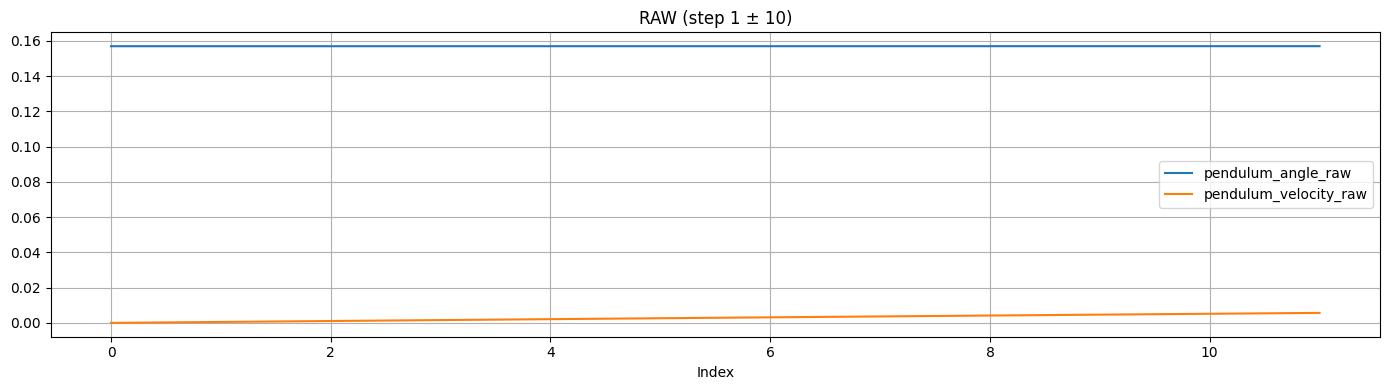

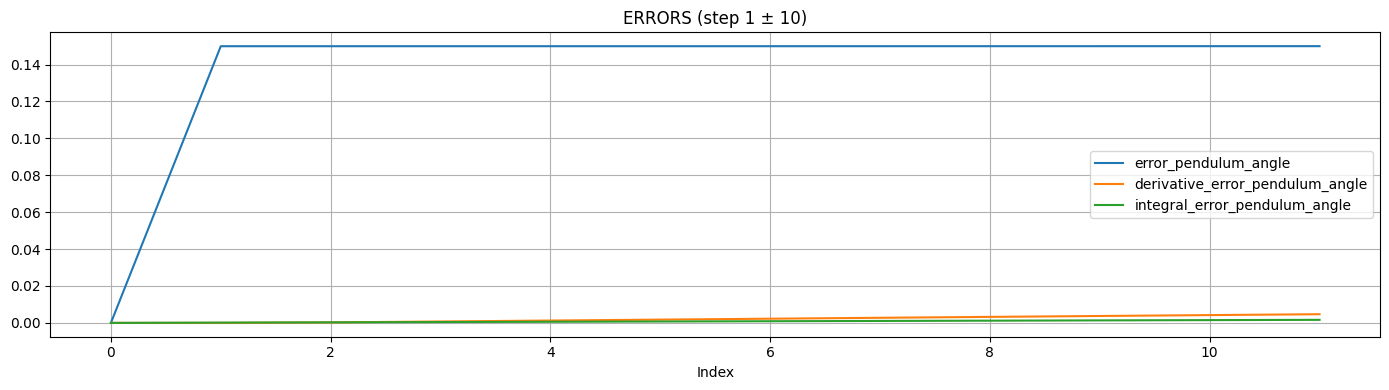

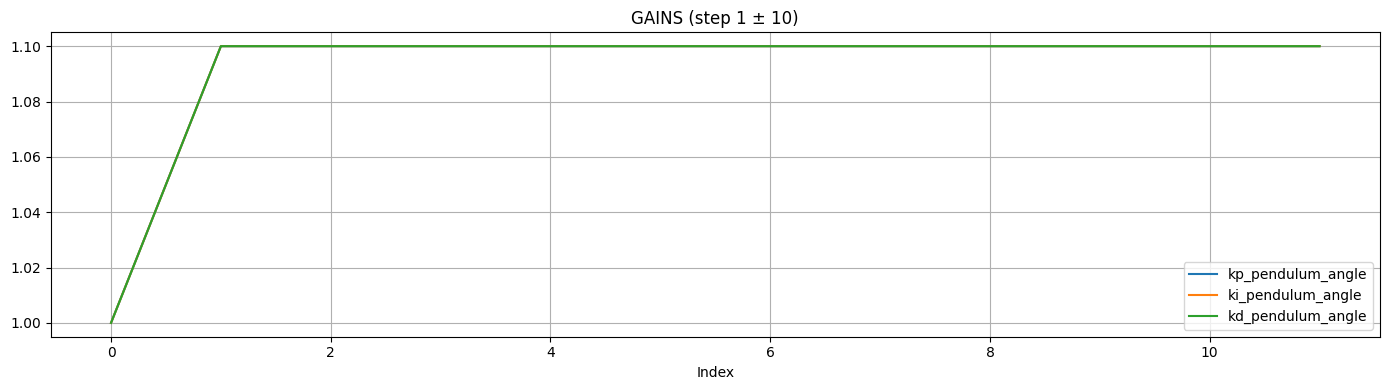

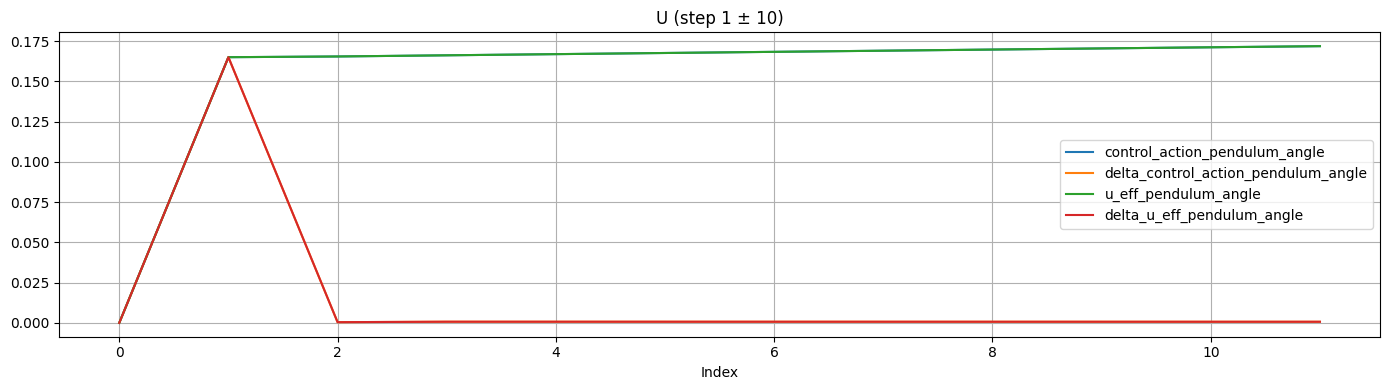


--- EVENT @ step 1881 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
1871,0.384455,0.482175,0.366666,0.459183,0.367231,5.5,2.4,5.8,5.561277,0.008359,5.561277,0.008359
1872,0.384937,0.483044,0.367126,0.460027,0.367598,5.5,2.4,5.8,5.569584,0.008307,5.569584,0.008307
1873,0.385421,0.483904,0.367587,0.460861,0.367965,5.5,2.4,5.8,5.577842,0.008257,5.577842,0.008257
1874,0.385905,0.484755,0.368049,0.461687,0.368333,5.5,2.4,5.8,5.586052,0.008210,5.586052,0.008210
1875,0.386390,0.485598,0.368511,0.462504,0.368702,5.5,2.4,5.8,5.594217,0.008166,5.594217,0.008166
1876,0.386876,0.486432,0.368975,0.463312,0.369071,5.5,2.4,5.8,5.602341,0.008124,5.602341,0.008124
1877,0.387363,0.487259,0.369439,0.464113,0.369440,5.5,2.4,5.8,5.610425,0.008084,5.610425,0.008084
1878,0.387851,0.488079,0.369904,0.464906,0.369810,5.5,2.4,5.8,5.618471,0.008046,5.618471,0.008046
1879,0.388339,0.488892,0.370369,0.465693,0.370181,5.5,2.4,5.8,5.626482,0.008011,5.626482,0.008011
1880,0.388829,0.489699,0.370836,0.466472,0.370551,5.5,2.4,5.8,5.634459,0.007977,5.634459,0.007977


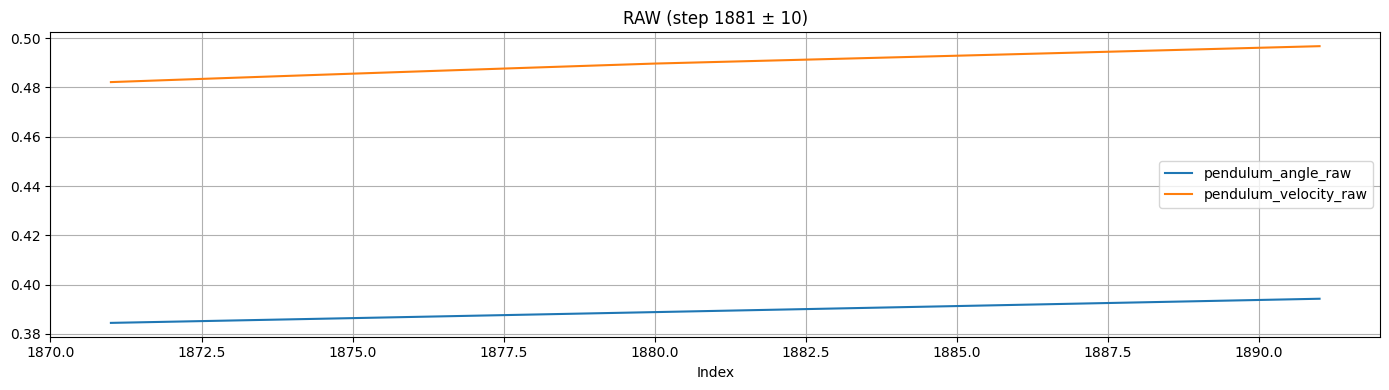

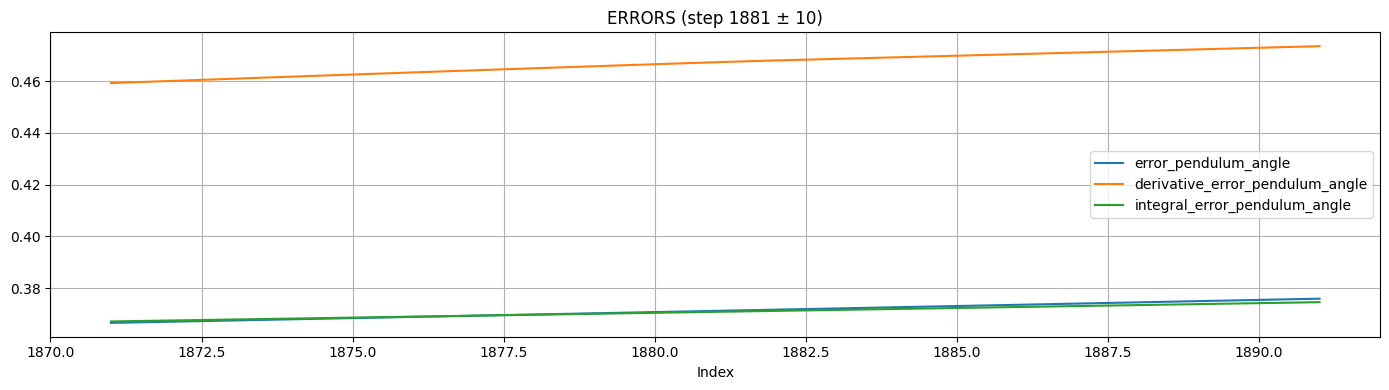

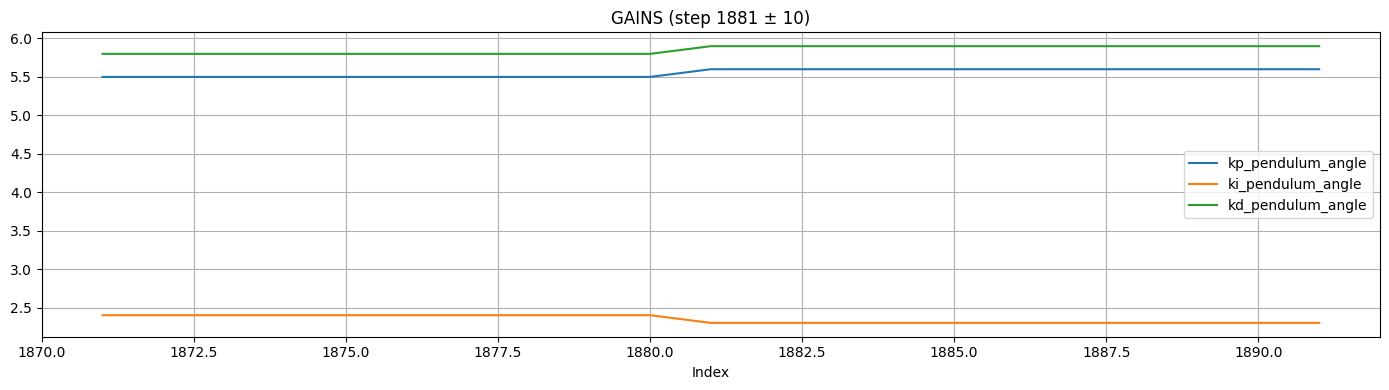

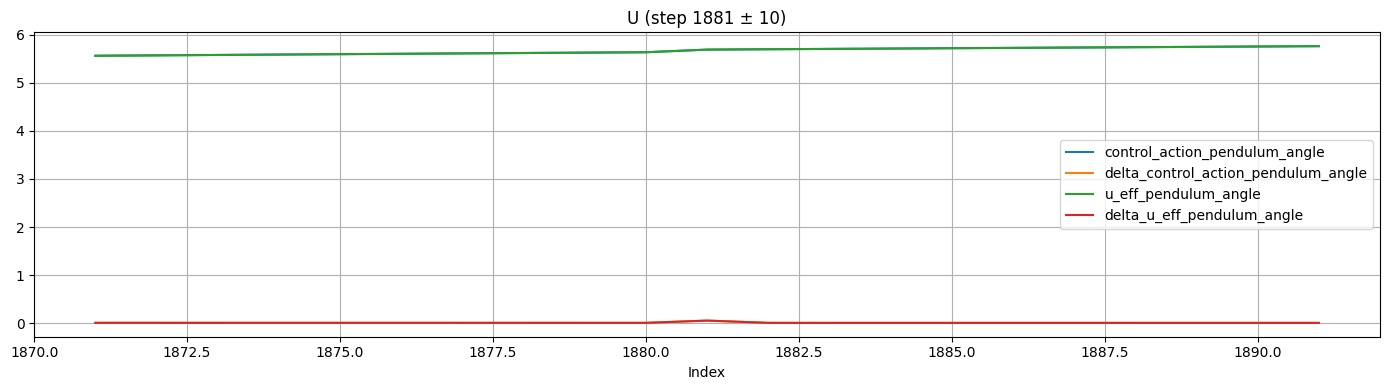


--- EVENT @ step 1981 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
1971,0.434814,0.522997,0.414717,0.498630,0.406300,5.8,2.3,5.9,6.281768,0.006923,6.281768,0.006923
1972,0.435337,0.523563,0.415216,0.499160,0.406715,5.8,2.3,5.9,6.288741,0.006973,6.288741,0.006973
1973,0.435861,0.524136,0.415716,0.499696,0.407131,5.8,2.3,5.9,6.295761,0.007021,6.295761,0.007021
1974,0.436386,0.524716,0.416216,0.500240,0.407547,5.8,2.3,5.9,6.302828,0.007067,6.302828,0.007067
1975,0.436911,0.525302,0.416717,0.500791,0.407964,5.8,2.3,5.9,6.309939,0.007111,6.309939,0.007111
1976,0.437436,0.525895,0.417218,0.501348,0.408381,5.8,2.3,5.9,6.317093,0.007154,6.317093,0.007154
1977,0.437963,0.526495,0.417720,0.501911,0.408799,5.8,2.3,5.9,6.324289,0.007195,6.324289,0.007195
1978,0.438489,0.527100,0.418222,0.502480,0.409217,5.8,2.3,5.9,6.331524,0.007236,6.331524,0.007236
1979,0.439017,0.527711,0.418725,0.503056,0.409636,5.8,2.3,5.9,6.338798,0.007274,6.338798,0.007274
1980,0.439545,0.528327,0.419229,0.503636,0.410055,5.8,2.3,5.9,6.346110,0.007312,6.346110,0.007312


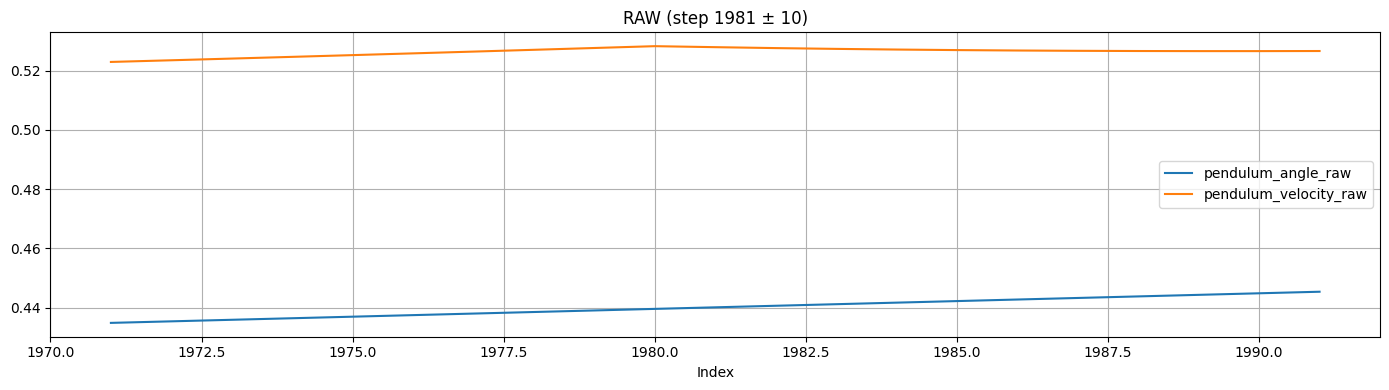

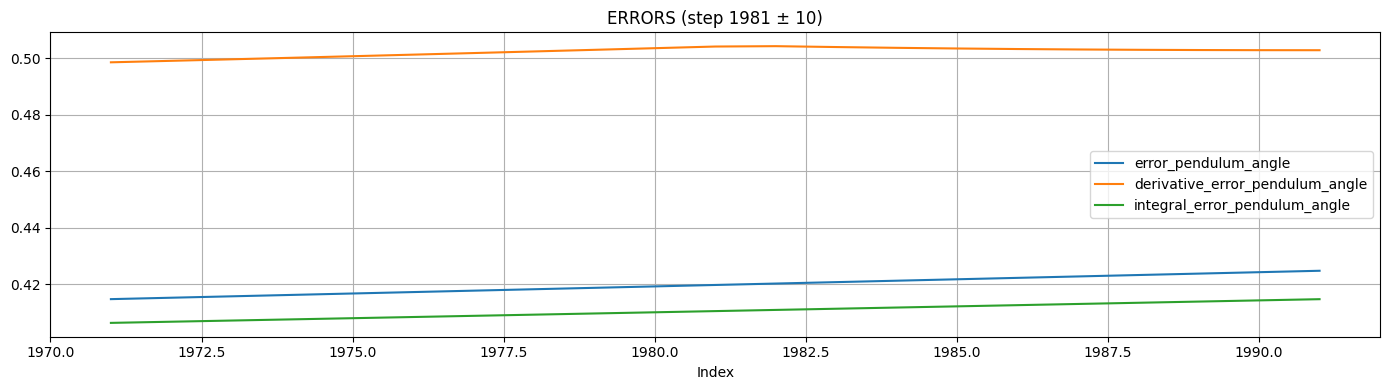

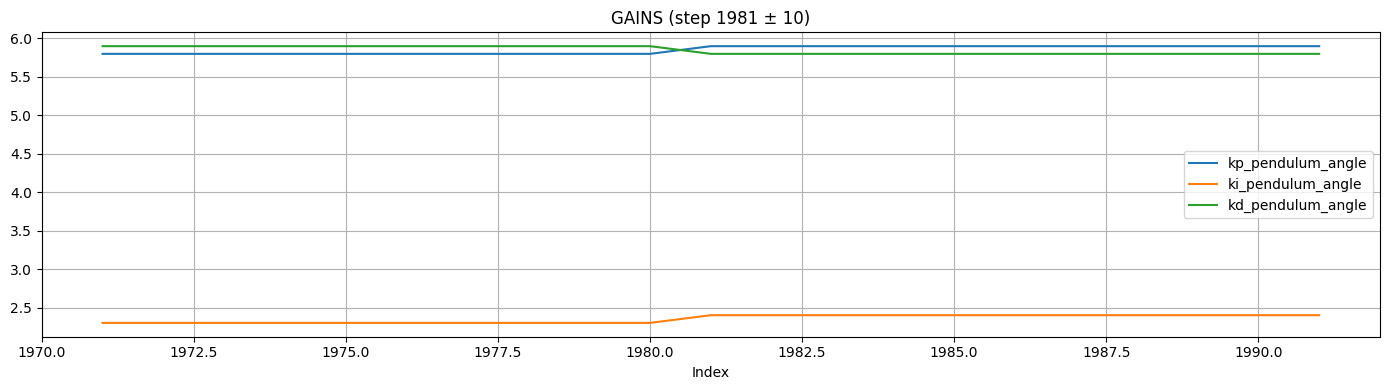

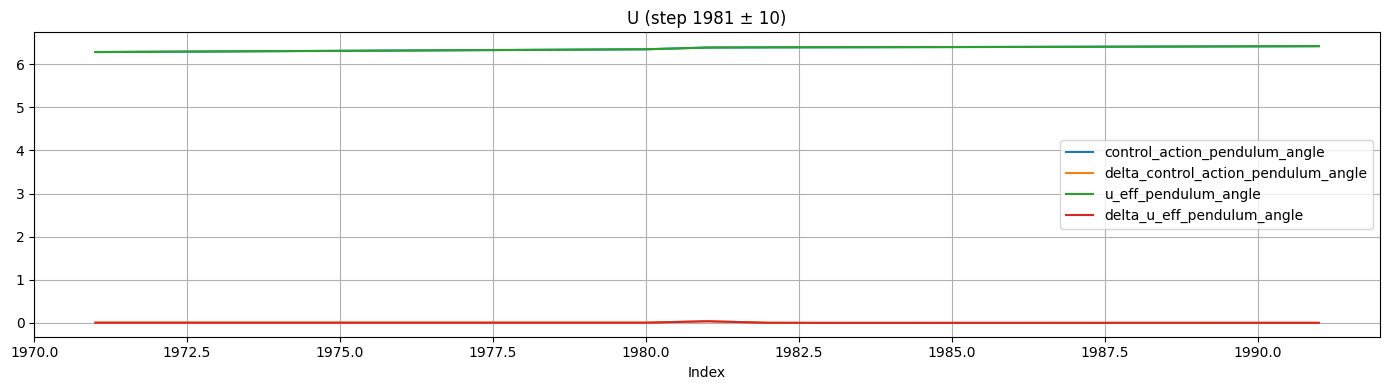


--- EVENT @ step 2081 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
2071,0.488715,0.583739,0.466131,0.555276,0.450330,5.7,2.4,6.0,7.069394,0.013136,7.069394,0.013136
2072,0.489300,0.585206,0.466688,0.556720,0.450797,5.7,2.4,6.0,7.082353,0.012959,7.082353,0.012959
2073,0.489886,0.586643,0.467246,0.558135,0.451264,5.7,2.4,6.0,7.095144,0.012791,7.095144,0.012791
2074,0.490473,0.588053,0.467805,0.559521,0.451732,5.7,2.4,6.0,7.107775,0.012631,7.107775,0.012631
2075,0.491062,0.589437,0.468366,0.560881,0.452200,5.7,2.4,6.0,7.120253,0.012478,7.120253,0.012478
2076,0.491652,0.590796,0.468928,0.562215,0.452669,5.7,2.4,6.0,7.132585,0.012333,7.132585,0.012333
2077,0.492243,0.592130,0.469492,0.563524,0.453138,5.7,2.4,6.0,7.144779,0.012194,7.144779,0.012194
2078,0.492836,0.593442,0.470057,0.564810,0.453608,5.7,2.4,6.0,7.156842,0.012063,7.156842,0.012063
2079,0.493430,0.594732,0.470623,0.566073,0.454079,5.7,2.4,6.0,7.168779,0.011937,7.168779,0.011937
2080,0.494026,0.596002,0.471190,0.567316,0.454550,5.7,2.4,6.0,7.180597,0.011818,7.180597,0.011818


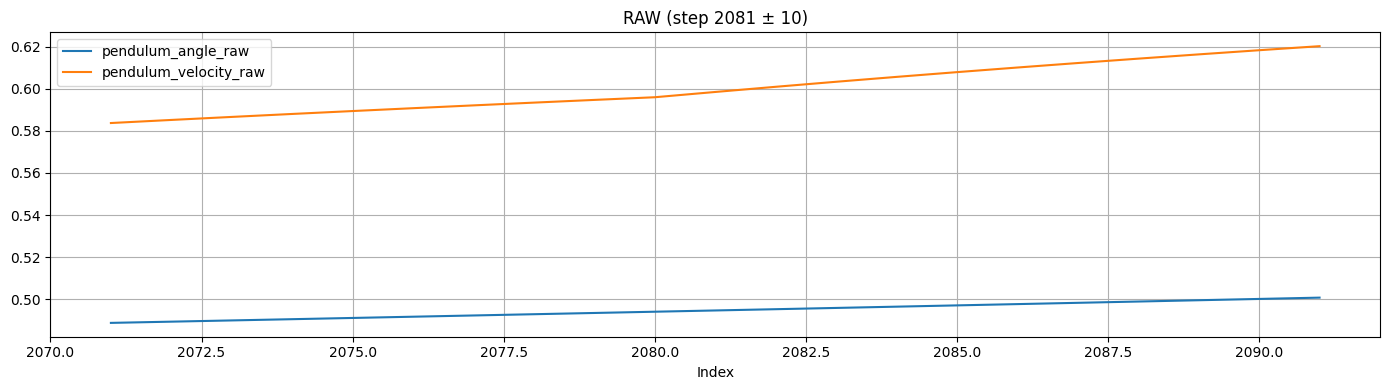

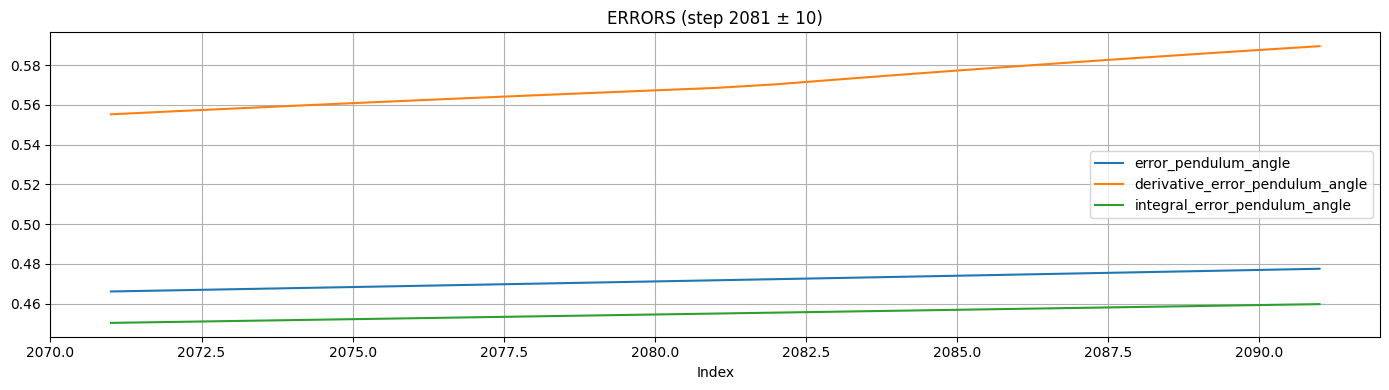

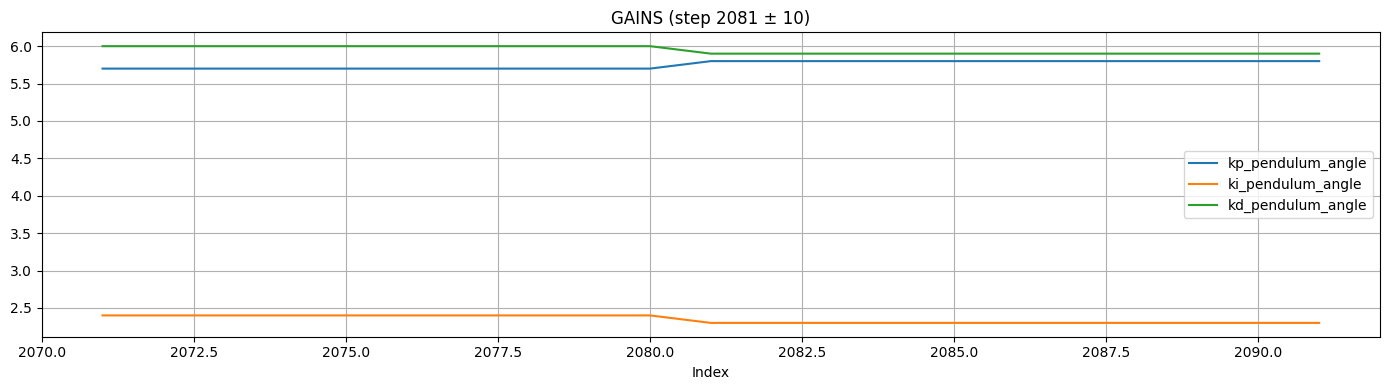

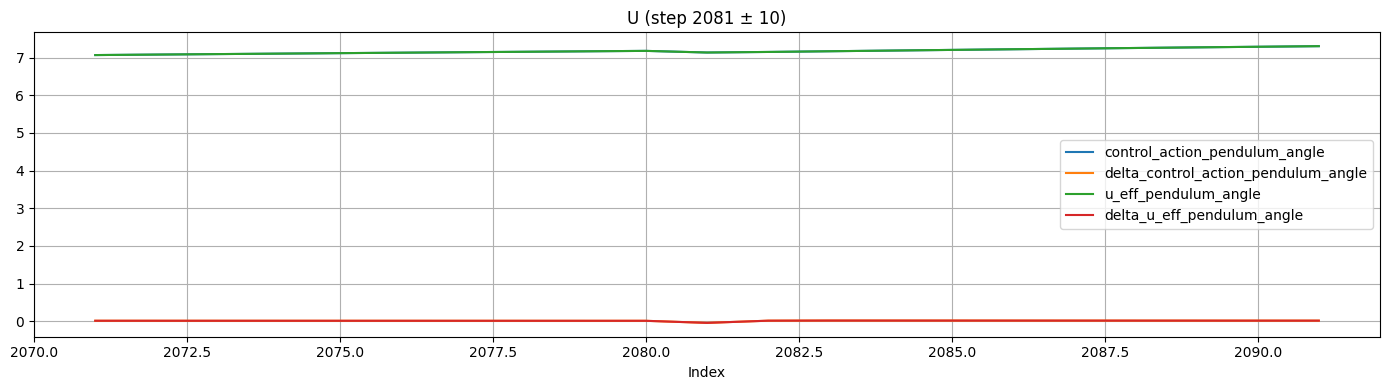


--- EVENT @ step 2201 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
2191,0.571697,0.796858,0.545170,0.758306,0.510802,5.8,2.4,6.0,8.937745,0.016519,8.937745,0.016519
2192,0.572495,0.798656,0.545930,0.760073,0.511348,5.8,2.4,6.0,8.954065,0.016320,8.954065,0.016320
2193,0.573295,0.800421,0.546691,0.761806,0.511894,5.8,2.4,6.0,8.970195,0.016130,8.970195,0.016130
2194,0.574096,0.802155,0.547455,0.763508,0.512442,5.8,2.4,6.0,8.986144,0.015949,8.986144,0.015949
2195,0.574899,0.803859,0.548220,0.765178,0.512990,5.8,2.4,6.0,9.001921,0.015777,9.001921,0.015777
2196,0.575704,0.805534,0.548987,0.766819,0.513539,5.8,2.4,6.0,9.017533,0.015613,9.017533,0.015613
2197,0.576510,0.807182,0.549755,0.768433,0.514089,5.8,2.4,6.0,9.032989,0.015456,9.032989,0.015456
2198,0.577318,0.808804,0.550525,0.770019,0.514639,5.8,2.4,6.0,9.048297,0.015307,9.048297,0.015307
2199,0.578128,0.810401,0.551297,0.771580,0.515190,5.8,2.4,6.0,9.063462,0.015165,9.063462,0.015165
2200,0.578939,0.811975,0.552070,0.773117,0.515743,5.8,2.4,6.0,9.078492,0.015030,9.078492,0.015030


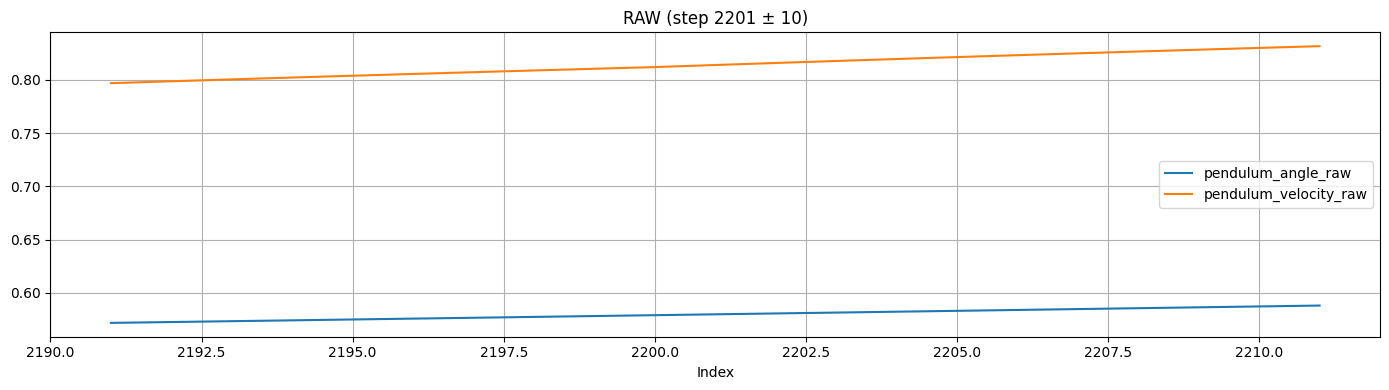

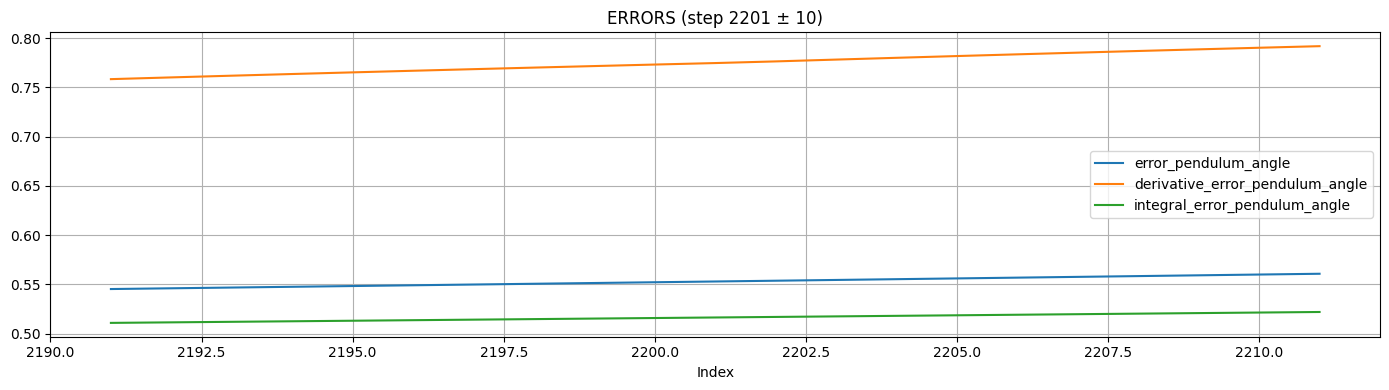

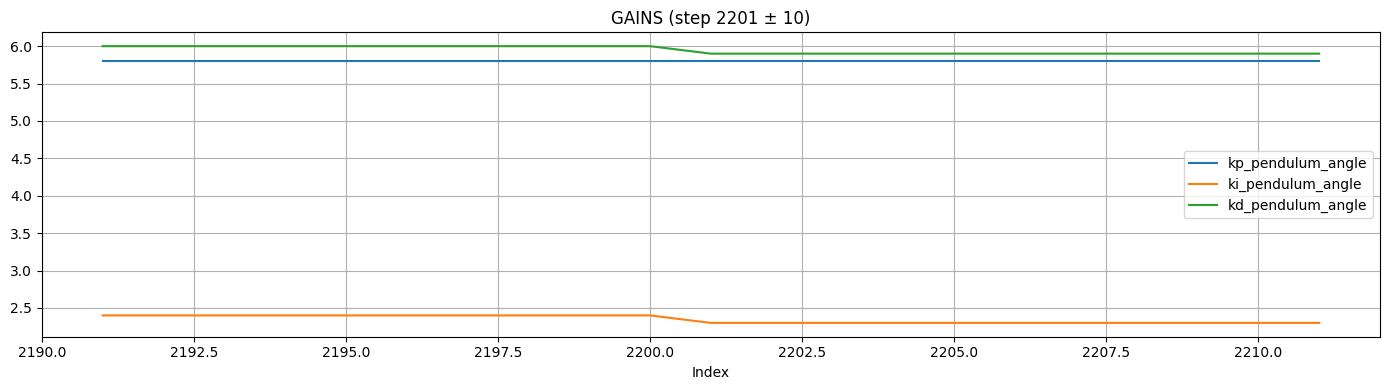

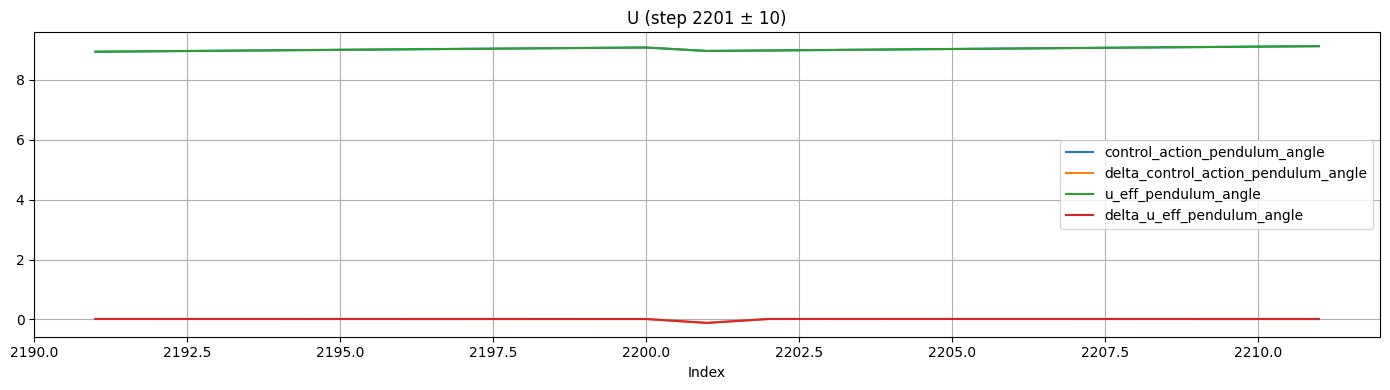


--- EVENT @ step 2281 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
2271,0.640656,0.917287,0.610904,0.874427,0.557014,5.9,2.4,5.9,10.100290,0.012569,10.100290,0.012569
2272,0.641574,0.918353,0.611780,0.875439,0.557626,5.9,2.4,5.9,10.112891,0.012601,10.112891,0.012601
2273,0.642492,0.919422,0.612656,0.876454,0.558239,5.9,2.4,5.9,10.125523,0.012632,10.125523,0.012632
2274,0.643412,0.920495,0.613534,0.877473,0.558852,5.9,2.4,5.9,10.138186,0.012663,10.138186,0.012663
2275,0.644333,0.921572,0.614412,0.878496,0.559467,5.9,2.4,5.9,10.150879,0.012693,10.150879,0.012693
2276,0.645256,0.922652,0.615292,0.879523,0.560082,5.9,2.4,5.9,10.163601,0.012723,10.163601,0.012723
2277,0.646179,0.923737,0.616172,0.880553,0.560698,5.9,2.4,5.9,10.176353,0.012752,10.176353,0.012752
2278,0.647103,0.924825,0.617054,0.881586,0.561315,5.9,2.4,5.9,10.189134,0.012781,10.189134,0.012781
2279,0.648028,0.925916,0.617936,0.882624,0.561933,5.9,2.4,5.9,10.201944,0.012810,10.201944,0.012810
2280,0.648955,0.927011,0.618820,0.883664,0.562552,5.9,2.4,5.9,10.214782,0.012838,10.214782,0.012838


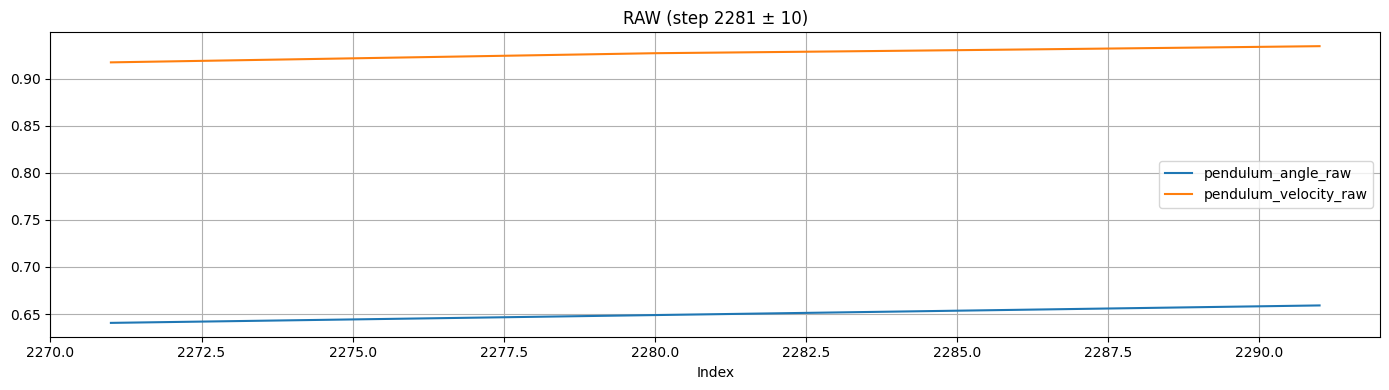

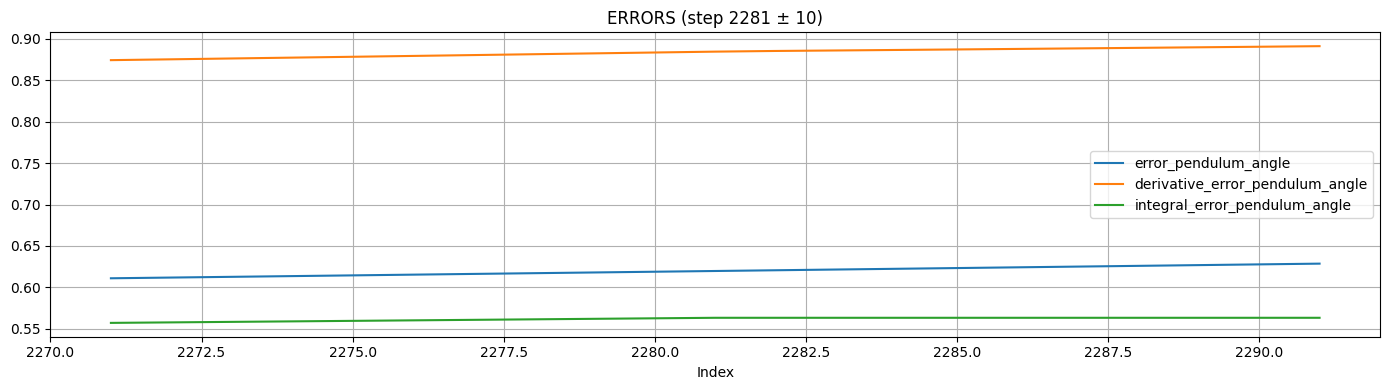

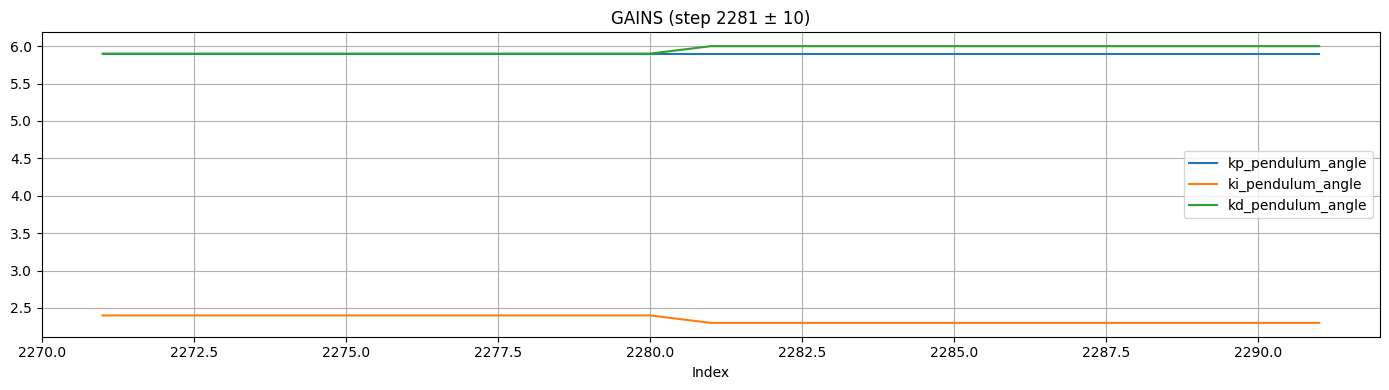

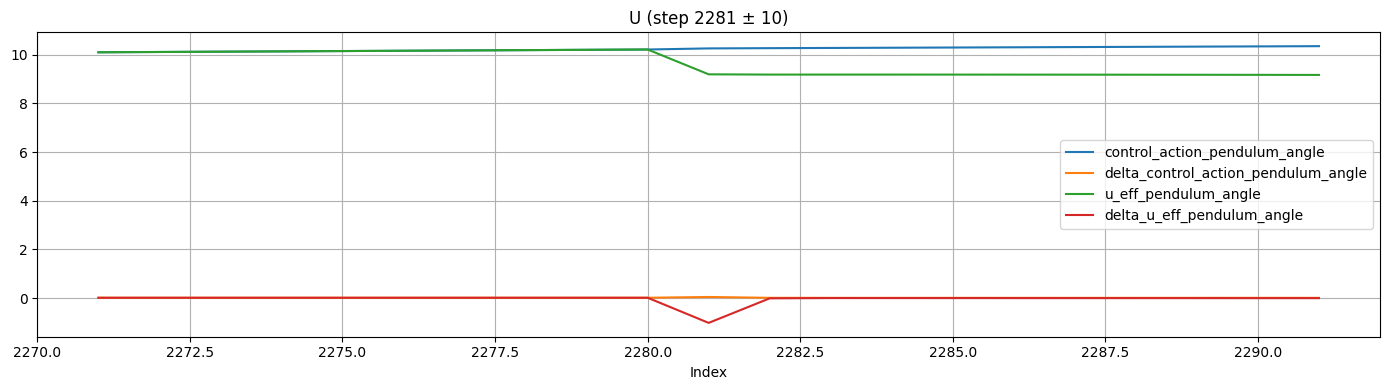


--- EVENT @ step 2361 ---


,pendulum_angle_raw,pendulum_velocity_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle,control_action_pendulum_angle,delta_control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle
2351,0.717040,1.001108,0.683766,0.953886,0.563172,5.8,2.4,5.9,10.945379,0.013725,9.694566,-0.034513
2352,0.718042,1.002594,0.684721,0.955286,0.563172,5.8,2.4,5.9,10.959183,0.013804,9.659820,-0.034746
2353,0.719045,1.004091,0.685678,0.956699,0.563172,5.8,2.4,5.9,10.973065,0.013882,9.624851,-0.034969
2354,0.720050,1.005601,0.686636,0.958123,0.563172,5.8,2.4,5.9,10.987026,0.013960,9.589668,-0.035183
2355,0.721056,1.007124,0.687596,0.959559,0.563172,5.8,2.4,5.9,11.001065,0.014039,9.554280,-0.035388
2356,0.722064,1.008659,0.688557,0.961007,0.563172,5.8,2.4,5.9,11.015183,0.014118,9.518695,-0.035585
2357,0.723074,1.010207,0.689519,0.962467,0.563172,5.8,2.4,5.9,11.029379,0.014197,9.482924,-0.035772
2358,0.724085,1.011767,0.690483,0.963939,0.563172,5.8,2.4,5.9,11.043655,0.014276,9.446973,-0.035950
2359,0.725097,1.013340,0.691448,0.965423,0.563172,5.8,2.4,5.9,11.058010,0.014355,9.410853,-0.036120
2360,0.726111,1.014925,0.692415,0.966919,0.563172,5.8,2.4,5.9,11.072444,0.014434,9.374571,-0.036282


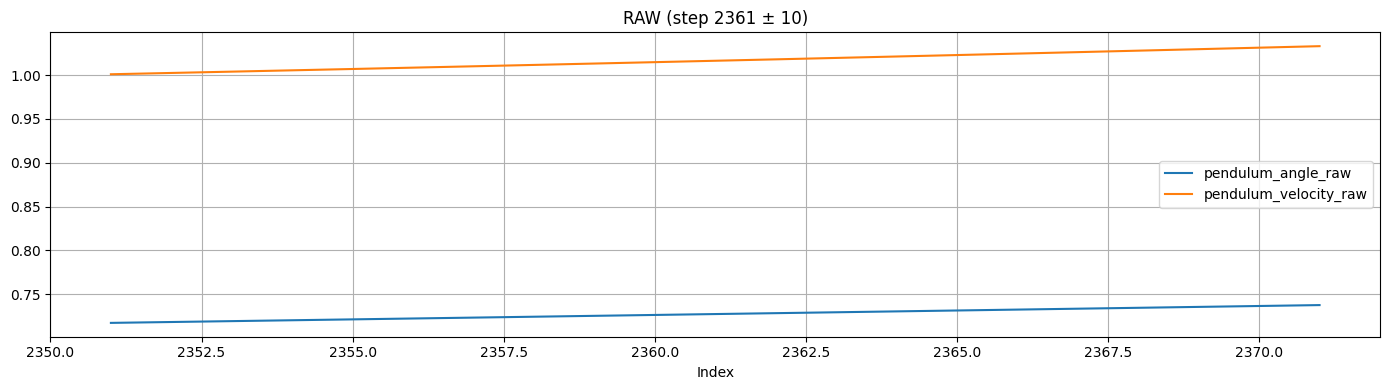

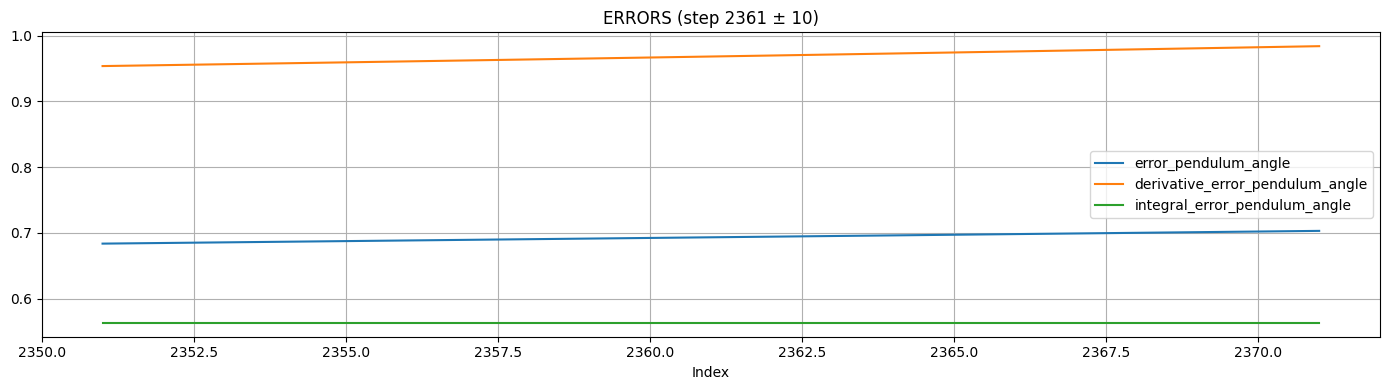

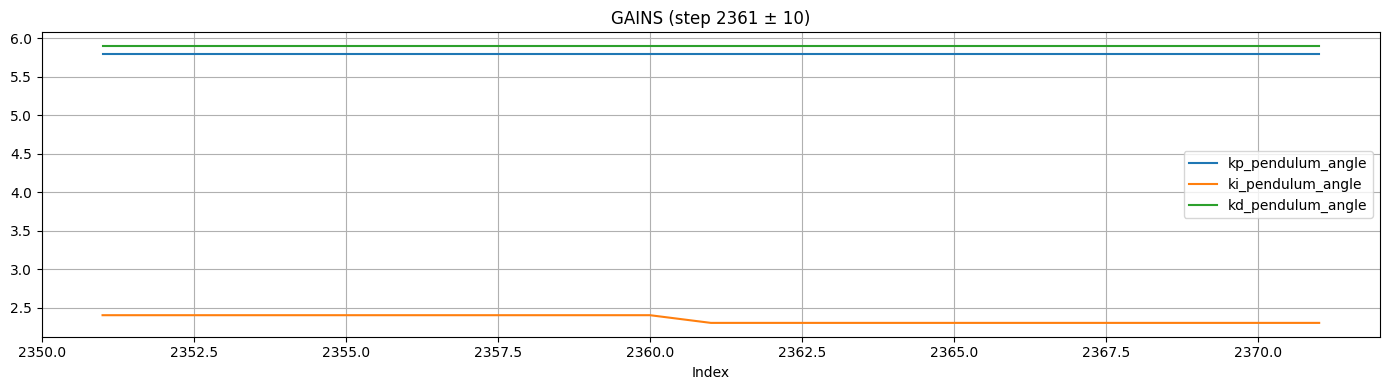

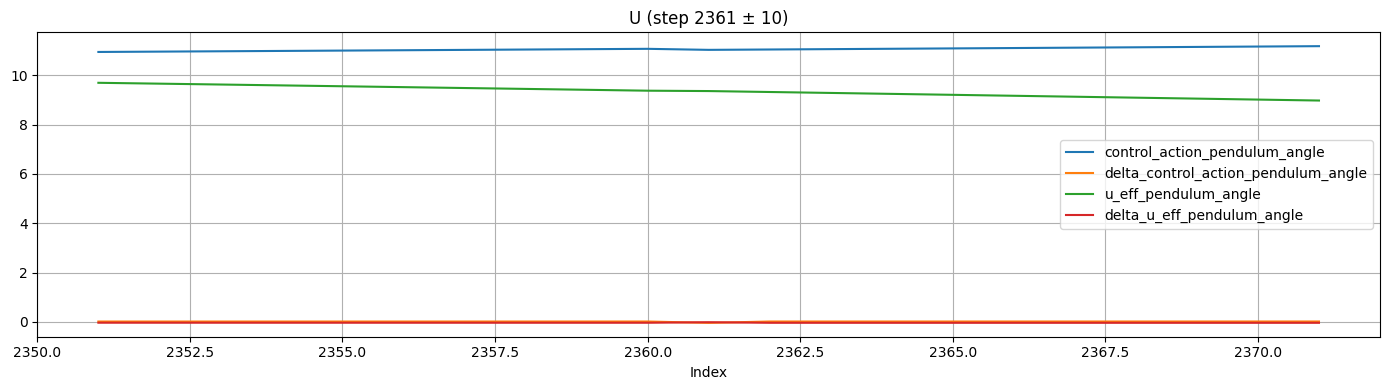

In [31]:
PIPE = {
    "Pendulum": {
        "gains":   ["kp_pendulum_angle", "ki_pendulum_angle", "kd_pendulum_angle"],
        "errors":  ["error_pendulum_angle", "derivative_error_pendulum_angle", "integral_error_pendulum_angle"],
        "u":       ["control_action_pendulum_angle", "delta_control_action_pendulum_angle",
                    "u_eff_pendulum_angle", "delta_u_eff_pendulum_angle"],
        "raw":     ["pendulum_angle_raw", "pendulum_velocity_raw"],
    },
    "Cart": {
        "gains":   ["kp_cart_position", "ki_cart_position", "kd_cart_position"],
        "errors":  ["error_cart_position", "derivative_error_cart_position", "integral_error_cart_position"],
        "u":       ["control_action_cart_position", "delta_control_action_cart_position",
                    "u_eff_cart_position", "delta_u_eff_cart_position"],
        "raw":     ["cart_position_raw", "cart_velocity_raw"],
    }
}

def plot_cols(df, cols, title="Plot", x_col=None, figsize=(14, 4)):
    x = df[x_col].to_numpy() if x_col and x_col in df.columns else np.arange(len(df))
    y_cols = [c for c in cols if c in df.columns]

    if not y_cols:
        return

    ax = df.plot(x=x_col if (x_col and x_col in df.columns) else None,
                 y=y_cols, figsize=figsize, title=title, grid=True)

    ax.set_xlabel(x_col if (x_col and x_col in df.columns) else "Index")
    plt.tight_layout()
    plt.show()
    
def cols_exist(df, cols): 
    return [c for c in cols if c in df.columns]

# --- 1) Vista “forense” de una ventana (elige idx) ---
def view_window(df, i, w=5, cols=None):
    a = max(0, i - w); b = min(len(df) - 1, i + w)
    return df.loc[a:b, cols] if cols else df.loc[a:b]

# --- 2) Plot secuencial por bloques (raw -> errors -> gains -> u) ---
def plot_pipeline(df, pipe, title_prefix="Pipeline", x_col=None):
    for block_name in ["raw", "errors", "gains", "u"]:
        cols = cols_exist(df, pipe.get(block_name, []))
        if cols:
            plot_walk(df, cols, x_col=x_col)  # usa tu plot_walk anterior

# --- 3) “Event-driven”: salta a puntos relevantes (saturación / grandes cambios de u) ---
def find_events(df, u_col, sat_col="is_saturated_global",
                top_du=20, min_gap=50):
    idx = set()

    if sat_col in df.columns:
        idx |= set(df.index[df[sat_col].astype(bool)])

    if u_col in df.columns:
        du = df[u_col].diff().abs()
        idx |= set(du.nlargest(top_du).index)

    idx = sorted(idx)
    # compacta para no mostrar puntos pegados
    out = []
    last = -10**9
    for i in idx:
        if i - last >= min_gap:
            out.append(i); last = i
    return out

# --- 4) Runner: para cada evento, muestra tabla + plots por bloque ---
def forensic_control_flow(df, pipe, events, w=5, x_col=None):
    # columnas que miras en tabla
    table_cols = cols_exist(df, sum([pipe.get(k, []) for k in ["raw","errors","gains","u"]], []))

    for i in events:
        print(f"\n--- EVENT @ step {i} ---")
        display(view_window(df, i, w=w, cols=table_cols))  # en notebook

        for block, cols in [("raw", pipe.get("raw", [])),
                            ("errors", pipe.get("errors", [])),
                            ("gains", pipe.get("gains", [])),
                            ("u", pipe.get("u", []))]:
            cols = cols_exist(df, cols)
            if cols:
                plot_cols(df.loc[max(0,i-w):min(len(df)-1,i+w), :], cols,
                          title=f"{block.upper()} (step {i} ± {w})",
                          x_col=x_col)

# --- 5) Uso (Péndulo) ---
p = PIPE["Pendulum"]

events = find_events(step_df,
                     u_col="u_eff_pendulum_angle" if "u_eff_pendulum_angle" in step_df.columns else "control_action_pendulum_angle",
                     sat_col="is_saturated_global",
                     top_du=25,
                     min_gap=80)

forensic_control_flow(step_df, p, events, w=10, x_col=None)

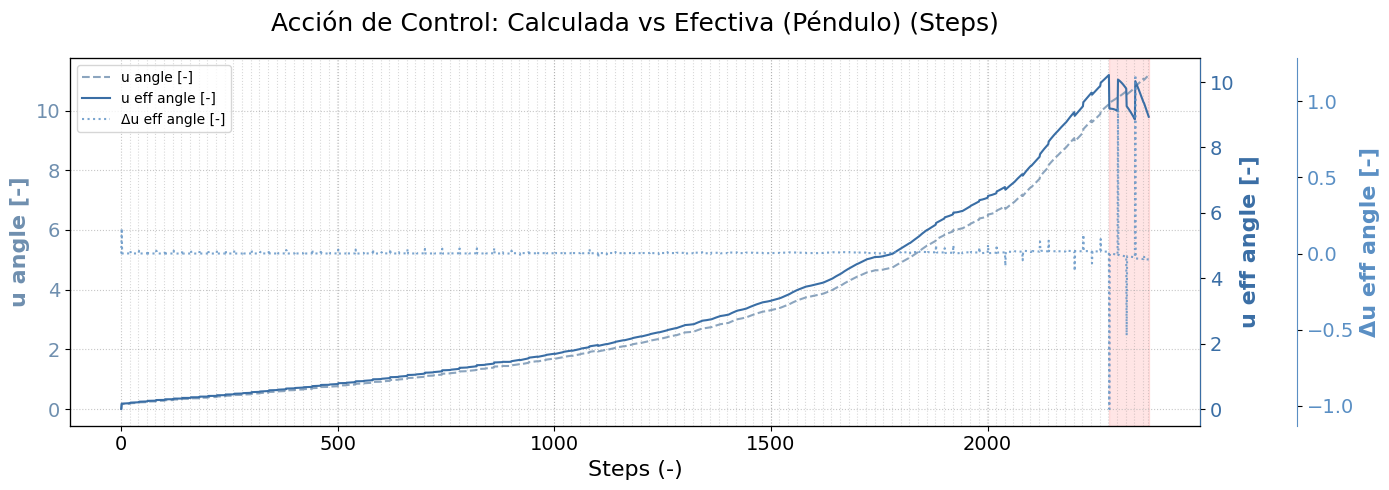

In [32]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['control_action_pendulum_angle', 'u_eff_pendulum_angle', 'delta_u_eff_pendulum_angle']

col_names = ['u angle [-]','u eff angle [-]', 'Δu eff angle [-]']

colors = ['#6F8FAF', '#3A6EA5', '#5A8FC4']
styles = ['--', '-', ':']
alphas  = [0.8, 1.0, 0.8]
title  = "Acción de Control: Calculada vs Efectiva (Péndulo) (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

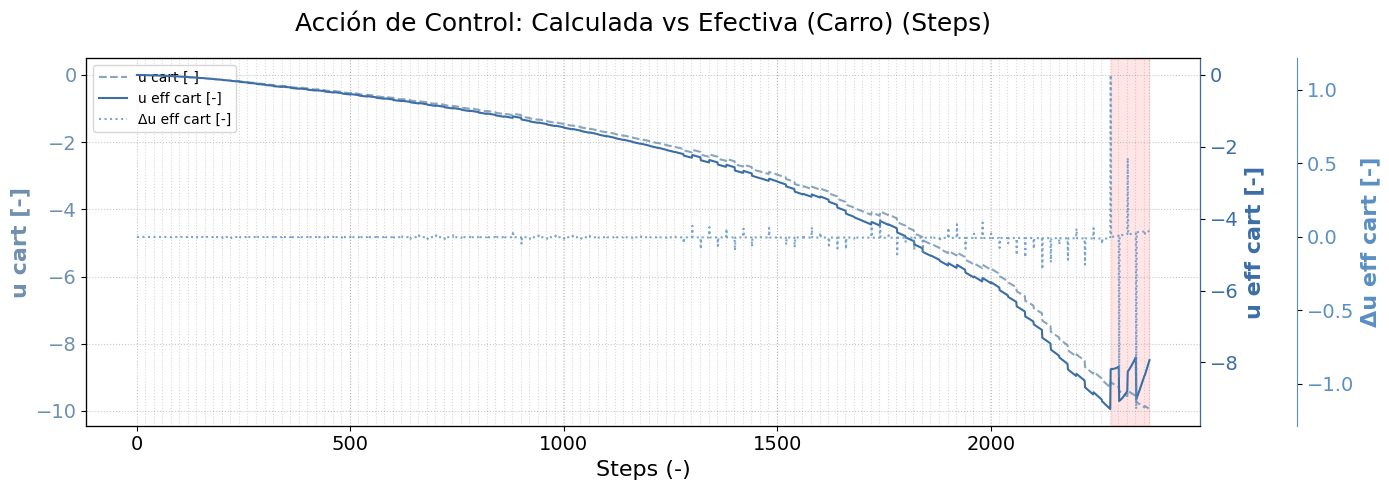

In [33]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['control_action_cart_position', 'u_eff_cart_position', 'delta_u_eff_cart_position']

col_names = ['u cart [-]', 'u eff cart [-]', 'Δu eff cart [-]']

colors = ['#6F8FAF', '#3A6EA5', '#5A8FC4']
styles = ['--', '-', ':']
alphas  = [0.8, 1.0, 0.8]
title  = "Acción de Control: Calculada vs Efectiva (Carro) (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

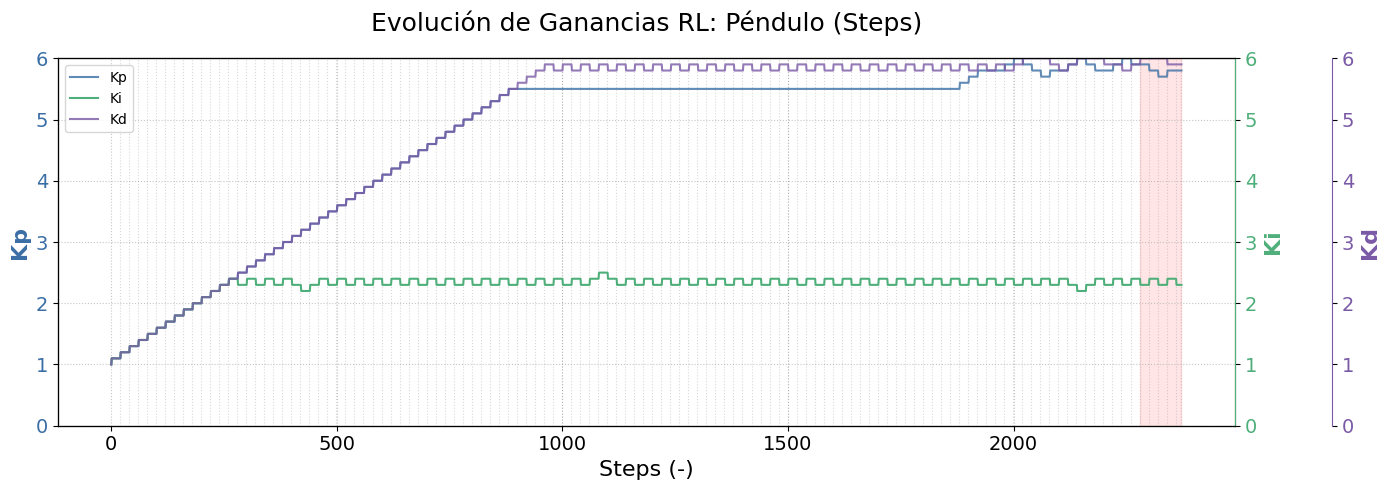

In [35]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['kp_pendulum_angle', 'ki_pendulum_angle', 'kd_pendulum_angle']
col_names    = ['Kp', 'Ki', 'Kd']

colors = ['#3A6EA5', '#4FAF7A', '#7A5AA6']
styles = ['-', '-', '-']
alpha  = [0.95, 0.95, 0.95]
title  = "Evolución de Ganancias RL: Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title, y_lim=[0, 6])

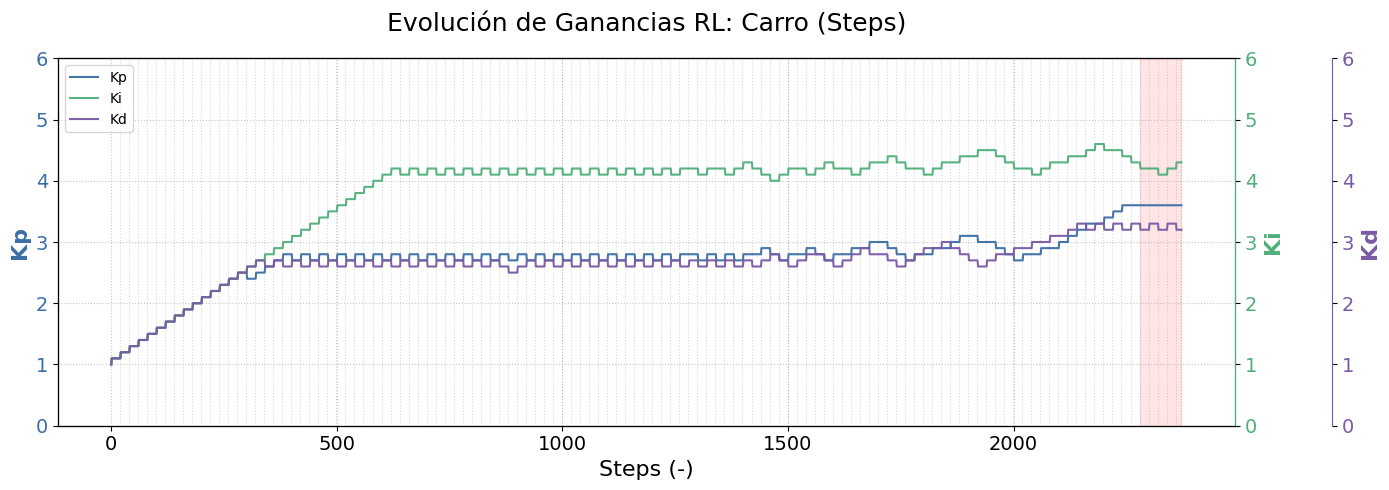

In [36]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['kp_cart_position', 'ki_cart_position', 'kd_cart_position']
col_names    = ['Kp', 'Ki', 'Kd']

colors = ['#3A6EA5', '#4FAF7A', '#7A5AA6']
styles = ['-', '-', '-']
alphas  = [0.95, 0.95, 0.95]
title  = "Evolución de Ganancias RL: Carro (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title, y_lim=[0, 6])

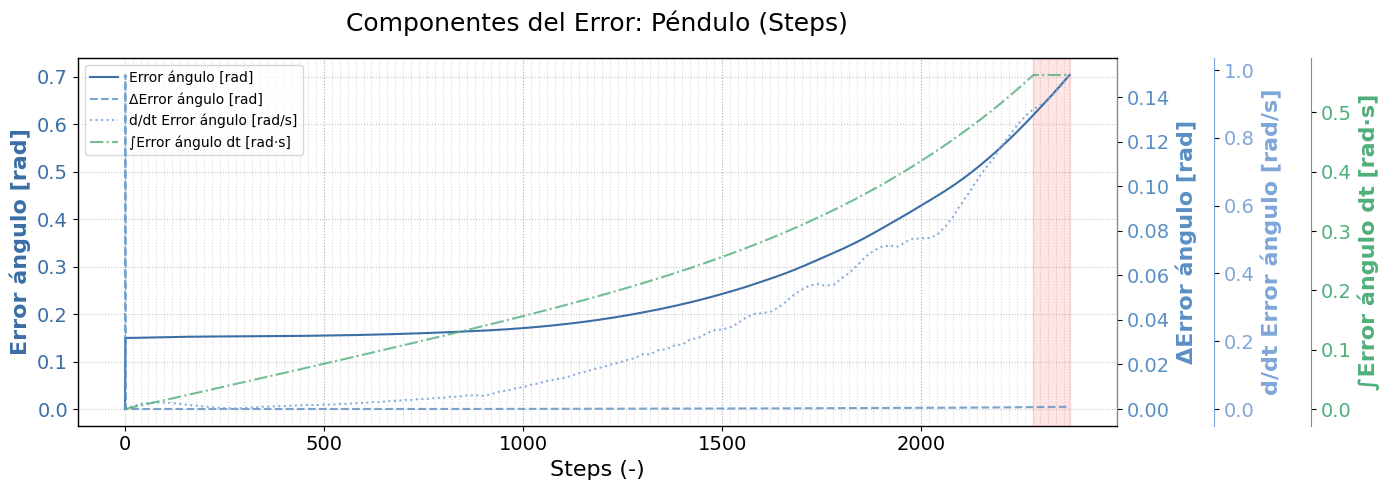

In [37]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['error_pendulum_angle', 'delta_error_pendulum_angle', 
                'derivative_error_pendulum_angle', 'integral_error_pendulum_angle']
col_names = ['Error ángulo [rad]', 'ΔError ángulo [rad]','d/dt Error ángulo [rad/s]', '∫Error ángulo dt [rad·s]']

colors = ['#3A6EA5', '#5A8FC4', '#7FA6D9', '#4FAF7A']
styles = ['-', '--', ':', '-.']
alphas  = [1.0, 0.8, 0.9, 0.8]
title  = "Componentes del Error: Péndulo (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

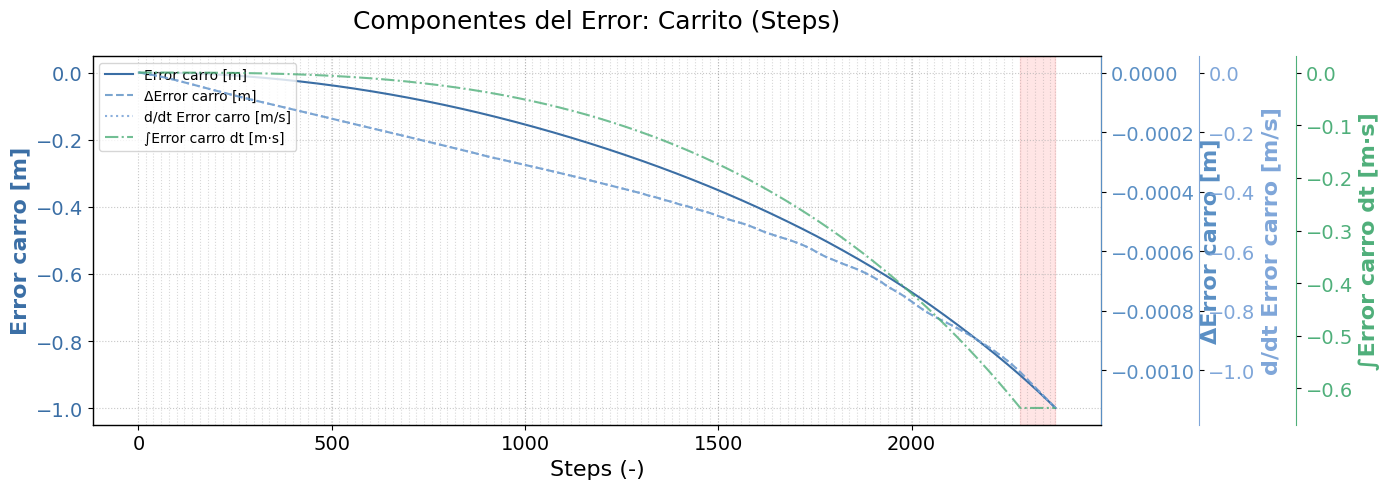

In [38]:
# --- CONFIGURACIÓN CELDA ---
cols_to_plot = ['error_cart_position',
                'delta_error_cart_position',
                'derivative_error_cart_position',
                'integral_error_cart_position']

col_names = ['Error carro [m]', 'ΔError carro [m]',
             'd/dt Error carro [m/s]', '∫Error carro dt [m·s]']

colors = ['#3A6EA5', '#5A8FC4', '#7FA6D9', '#4FAF7A']
styles = ['-', '--', ':', '-.']
alphas  = [1.0, 0.8, 0.9, 0.8]
title  = "Componentes del Error: Carrito (Steps)"

# --- LLAMADA ---
plot_many_columns(step_df, cols_to_plot, colors, styles, alphas, col_names=col_names, title=title)

### Sanity check: Reward Data

In [ ]:
y_cols_cart = ['L_e_cart_position', 'L_edot_cart_position', 'L_delta_u_cart_position', 'reward_kp_cart_position']

x = interval_timeline_df['interval_id'].to_numpy()
ax = interval_timeline_df.plot(x='interval_id', y=y_cols_cart, figsize=(10, 3), grid=True)

ax.set_xlabel('Interval')
ax.set_title('Reward Components - Cart Position')
plt.tight_layout()
plt.show()

In [ ]:
# Recompensa global por intervalo
ax = interval_timeline_df.plot(x='interval_id', y='global_interval_reward', figsize=(10, 3), grid=True, color='purple')
ax.set_xlabel('Interval')
ax.set_title('Global Interval Reward')
plt.tight_layout()
plt.show()

## Caja 7 - Análisis de Episodios (Global)
- Extraemos las métricas finales (`end_episode_data`) de todos los episodios iterando sobre los chunks encontrados.
- Generamos un DataFrame global para ver la evolución del entrenamiento y del Reward.

In [ ]:
# Cargar un resumen de todos los episodios
global_records = []

for cf in chunk_files:
    try:
        chunk_data = load_json(cf)
        for ep in chunk_data:
            ep_id = extract_episode_id(ep)
            end_data = ep.get('end_episode_data', {})
            
            record = {'episode_id': ep_id}
            if end_data:
                record.update(end_data)
            
            global_records.append(record)
    except Exception as e:
        print(f"Error cargando {cf}: {e}")

global_df = pd.DataFrame(global_records).sort_values('episode_id').reset_index(drop=True)
print(f"Total episodios cargados: {len(global_df)}")
global_df.head()

In [ ]:
# Gráfico de evolución del Total Reward a lo largo de los episodios
fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(global_df['episode_id'], global_df['total_reward'], color='tab:blue', alpha=0.6, label='Total Reward')
ax1.set_xlabel('Episode ID')
ax1.set_ylabel('Total Reward', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Epsilon en otro eje Y, si está presente
if 'epsilon' in global_df.columns:
    ax2 = ax1.twinx()
    ax2.plot(global_df['episode_id'], global_df['epsilon'], color='tab:orange', linewidth=2, label='Epsilon')
    ax2.set_ylabel('Epsilon', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Evolución del Reward Total y Epsilon por Episodio')
fig.tight_layout()
plt.show()

In [ ]:
# Razón de terminación de los episodios (estadísticas)
if 'end_termination_reason' in global_df.columns:
    term_counts = global_df['end_termination_reason'].value_counts()
    print("Razones de terminación de episodio:")
    print(term_counts)
    
    # Gráfico de torta
    term_counts.plot.pie(autopct='%1.1f%%', figsize=(5,5))
    plt.title('Termination Reasons')
    plt.ylabel('')
    plt.show()